/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Nodes: 21834, Corps: 2450, Dim: 1088
Initializing corporate vectors with patent means...

>>> Training Started...
Epoch 01 | Loss: 48.8846 | MRR: 0.0611 | Consist: 0.989
Epoch 02 | Loss: 48.4088 | MRR: 0.0858 | Consist: 0.980
Epoch 03 | Loss: 49.5366 | MRR: 0.0655 | Consist: 0.986
Epoch 04 | Loss: 41.8598 | MRR: 0.0645 | Consist: 0.989
Epoch 05 | Loss: 48.3015 | MRR: 0.0623 | Consist: 0.985
Epoch 06 | Loss: 48.2660 | MRR: 0.0664 | Consist: 0.986
Epoch 07 | Loss: 46.9268 | MRR: 0.0657 | Consist: 0.984
Epoch 08 | Loss: 47.4997 | MRR: 0.0515 | Consist: 0.985
Epoch 09 | Loss: 48.4812 | MRR: 0.0644 | Consist: 0.986
Epoch 10 | Loss: 49.6712 | MRR: 0.0520 | Consist: 0.982
Epoch 11 | Loss: 49.0965 | MRR: 0.0548 | Consist: 0.983
Epoch 12 | Loss: 47.5617 | MRR: 0.0584 | Consist: 0.982
Epoch 13 | Loss: 48.5317 | MRR: 0.

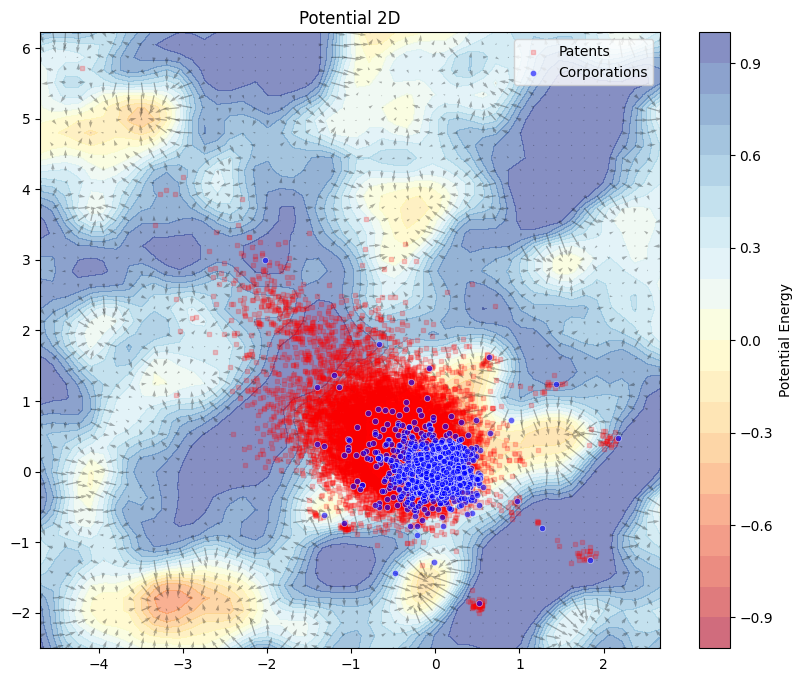

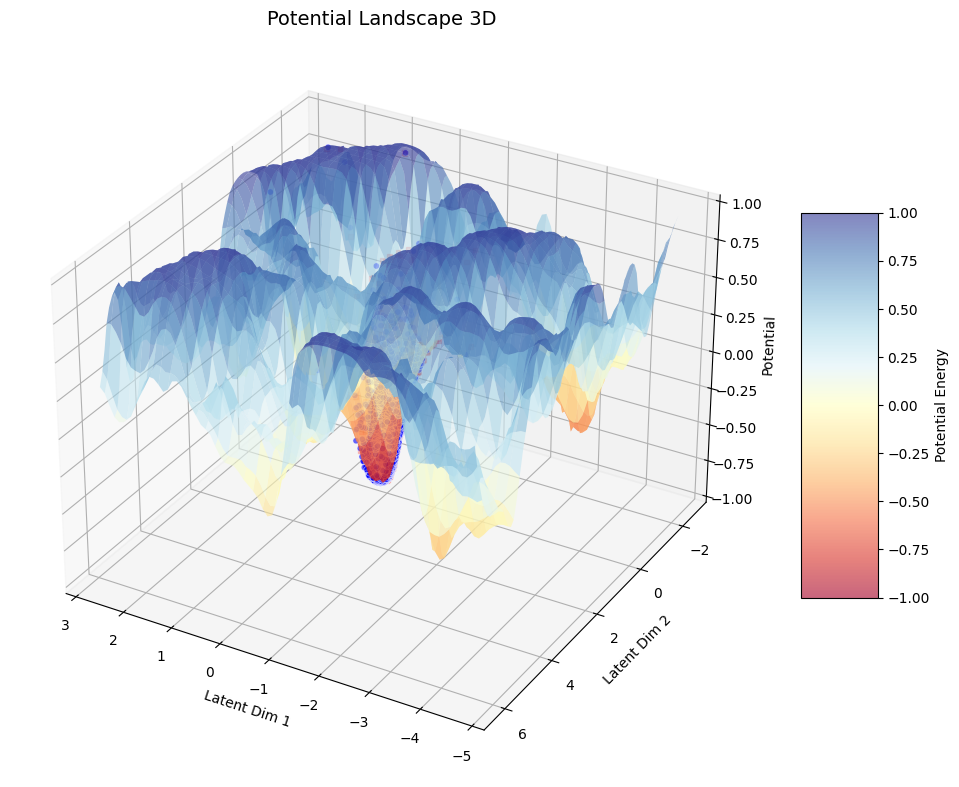

In [1]:
import time
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from mpl_toolkits.mplot3d import Axes3D  # 3Dプロット用

# 基本設定
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ============================================================
# 1. データ前処理
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルの文字列を安全にパースする"""
    if pd.isna(x) or x == "":
        return None
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    print("1. データ読み込み開始...")
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"エラー: ファイル '{file_path}' が見つかりません。")
        return pd.DataFrame()

    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row.get('description_embedding', ''))
        meta = safe_parse_embedding(row.get('metadata_embedding', ''))
        
        if desc is not None and meta is not None:
            if len(desc) > 0 and len(meta) > 0:
                combined_vectors.append(np.concatenate([desc, meta]))
                valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("警告: 有効なベクトルデータがありません。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return [x] if isinstance(x, str) else x
    
    if "corporation" in df.columns:
        df["corporation"] = df["corporation"].apply(parse_corp)
        df["corporation"] = df["corporation"].apply(lambda x: x if isinstance(x, list) else [])
    
    if "year_month" in df.columns:
        df['year_month'] = pd.to_datetime(df['year_month'], errors='coerce')
        df = df.dropna(subset=['year_month'])
        df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    print(f"✓ 前処理完了: {len(df)} 件")
    return df

def calculate_initial_corp_vectors(df, num_corps, input_dim, all_corporations):
    """
    企業の初期ベクトルを「保有特許の平均」で計算する関数
    """
    print("Initializing corporate vectors with patent means...")
    corp_vectors = np.zeros((num_corps, input_dim), dtype=np.float32)
    corp_counts = np.zeros(num_corps, dtype=np.float32)
    
    # Corp名 -> Index のマップ
    corp_to_idx = {c: i for i, c in enumerate(all_corporations)}
    
    for _, row in df.iterrows():
        vec = row['combined_vector']
        if vec is None or len(vec) != input_dim: continue
        
        corps = row['corporation']
        for c in corps:
            if c in corp_to_idx:
                idx = corp_to_idx[c]
                corp_vectors[idx] += vec
                corp_counts[idx] += 1
    
    # 平均化 (特許がない企業はゼロのまま、あるいはランダムノイズを加える)
    for i in range(num_corps):
        if corp_counts[i] > 0:
            corp_vectors[i] /= corp_counts[i]
        else:
            # 特許がない場合は小さなランダム値で初期化
            corp_vectors[i] = np.random.normal(0, 0.01, input_dim)
            
    return torch.tensor(corp_vectors, dtype=torch.float32)

# ============================================================
# 2. モデルコンポーネント定義
# ============================================================

# --- GAT Encoder ---
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# --- PotentialNet (With Grid Computation) ---
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        # Random Fourier Features (RFF) 用の周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim # sin/cos projectionにより次元が決定
        
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1),
            nn.Tanh()
        )

    def forward(self, z):
        # 座標 z を高周波空間へ射影
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        # モデル入力用にフラット化
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        
        # ポテンシャル計算
        model_device = next(self.parameters()).device
        with torch.no_grad():
            potentials = self.forward(grid_points.to(model_device))
        
        return (
            X.cpu().numpy(), 
            Y.cpu().numpy(), 
            potentials.view(resolution, resolution).cpu().numpy()
        )

# --- GradientODEFunc (With Gradient Field Computation) ---
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        # 勾配フロー: dz/dt = -grad(Phi)
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        
        # tanhで勾配の大きさを制限し、学習を安定化
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device
        )
        grid_points.requires_grad_(True)
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        # Hamiltonian/Gradient Flowにおける「移動方向」は -gradient
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        # odeintで積分し、最後の時刻の状態を返す
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# 2. 共通モジュール (Encoder / Base Class)
# ============================================================
class SharedEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv_mu = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels * 2, out_channels, heads=1, concat=False)
        self.bn = nn.BatchNorm1d(hidden_channels * 2)

    def forward(self, x, edge_index):
        x = F.elu(self.bn(self.conv1(x, edge_index)))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)
    
class BaseDynamicVGAE(nn.Module):
    """全てのモデルの親クラス"""
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業埋め込み
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedEncoder(input_dim, hidden_dim, latent_dim)

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index):
        x = self.get_node_features(x)
        mu, logvar = self.encoder(x, edge_index)
        z = mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar) if self.training else mu
        return z, mu, logvar

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        return torch.sigmoid((z_src * z_dst).sum(dim=1))

    def predict_future(self, z_history):
        """モデルごとに実装"""
        raise NotImplementedError

# ============================================================
# 3.4つのモデル定義
# ============================================================
# --- 1. Static VGAE (時間依存なし) ---
class StaticVGAE(BaseDynamicVGAE):
    def predict_future(self, z_history):
        # 予測しない（現在の値をそのまま返す）
        return z_history[-1]

# --- 2. VGRNN (離散時間 / LSTM) ---
class VGRNN(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        self.lstm = nn.LSTM(input_size=latent_dim, hidden_size=hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, latent_dim)

    def predict_future(self, z_history):
        # z_history: List of [N, latent_dim] -> Tensor [N, Seq, latent_dim]
        # ノードごとに独立した時系列として扱う
        seq_tensor = torch.stack(z_history, dim=1)
        out, _ = self.lstm(seq_tensor)
        # 最後のタイムステップの出力を使用
        return self.fc_out(out[:, -1, :])

# --- 3. Standard GODE (連続時間 / 物理なし) ---
class ODEFuncNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, t, z):
        return self.net(z)

class StandardGODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
       # 独立したModuleとして定義
        self.ode_func_module = ODEFuncNet(latent_dim, hidden_dim)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device) # 1ステップ先へ
        z_next = odeint(self.ode_func_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class PotentialGradientFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return -grad_z
    
# --- 4. Proposed (Potential ODE) (連続時間 / 物理あり) ---
class ProposedPotentialODE(BaseDynamicVGAE):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=64, latent_dim=2):
        super().__init__(num_nodes, num_corps, input_dim, hidden_dim, latent_dim)
        # ポテンシャル場 Phi(z)
        self.potential_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        # ODE関数ラッパーに potential_net を渡す
        self.ode_gradient_module = PotentialGradientFunc(self.potential_net)

    def predict_future(self, z_history):
        z_curr = z_history[-1]
        t_span = torch.tensor([0., 1.0], device=z_curr.device)
        z_next = odeint(self.ode_gradient_module, z_curr, t_span, method='rk4', rtol=1e-3, atol=1e-3)[-1]
        return z_next

# ============================================================
# 4. 学習・評価ロジック
# ============================================================
def compute_metrics(model, z_pred, pos_edge_index, num_corps, num_nodes):
    """AUCと簡易MRRを計算"""
    model.eval()
    
    # 評価対象: 企業->特許のエッジ
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) < 2: return 0.5, 0.0

    # サンプリング数を制限して高速化
    num_samples = min(eval_edges.size(1), 500)
    indices = torch.randperm(eval_edges.size(1))[:num_samples]
    src, dst = eval_edges[0, indices], eval_edges[1, indices]

    # --- AUC ---
    with torch.no_grad():
        pos_scores = model.decode(z_pred, torch.stack([src, dst])).cpu().numpy()
        
        neg_dst = torch.randint(num_corps, num_nodes, src.size(), device=device)
        neg_scores = model.decode(z_pred, torch.stack([src, neg_dst])).cpu().numpy()
    
    y_true = np.concatenate([np.ones(len(pos_scores)), np.zeros(len(neg_scores))])
    y_scores = np.concatenate([pos_scores, neg_scores])
    auc = roc_auc_score(y_true, y_scores)

    # --- MRR (簡易版: 1 vs 99) ---
    ranks = []
    with torch.no_grad():
        for s, d, p_score in zip(src, dst, pos_scores):
            # 負例候補99個
            neg_cands = torch.randint(num_corps, num_nodes, (99,), device=device)
            # ターゲット(正解)を追加
            cands = torch.cat([d.view(1), neg_cands])
            src_repeated = s.repeat(100)
            
            all_scores = model.decode(z_pred, torch.stack([src_repeated, cands]))
            # 正解(index 0)よりスコアが高いものの数 + 1
            rank = (all_scores > all_scores[0]).sum().item() + 1
            ranks.append(1.0 / rank)
            
    mrr = np.mean(ranks)
    return auc, mrr

def train_comparison(config, num_epochs=30, latent_dim=16):
    """全モデルを比較学習"""
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "Proposed": ProposedPotentialODE
    }
    
    results = {}
    years = sorted(config['graphs'].keys())
    train_years = years[:-2] # 最後2つを検証用
    
    for name, model_cls in models.items():
        print(f"\n[{name}] Training Start...")
        model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], hidden_dim=64, latent_dim=latent_dim).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)
        
        history = {'loss': [], 'auc': [], 'mrr': []}
        
        for epoch in range(num_epochs):
            model.train()
            epoch_loss = 0
            
            # --- Training Loop ---
            for i in range(len(train_years) - 1):
                y_t = train_years[i]
                y_next = train_years[i+1]
                
                data_t = config['graphs'][y_t].to(device)
                data_next = config['graphs'][y_next].to(device)
                
                # 履歴作成 (過去3ステップ分)
                z_hist = []
                # 直近3つのグラフをEncodeして latent vector を取得
                hist_years = range(max(years[0], y_t - 2), y_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist.append(z)
                
                # Padding if history is short (for LSTM/RNN consistency)
                while len(z_hist) < 3:
                    z_hist.insert(0, z_hist[0]) 

                optimizer.zero_grad()
                
                # 1. Reconstruction Loss (Current Time)
                z_t = z_hist[-1] # Current latent
                pos_pred = model.decode(z_t, data_t.edge_index)
                neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                neg_pred = model.decode(z_t, neg_idx)
                recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                
                # 2. Future Prediction Loss
                loss_pred = torch.tensor(0.0, device=device)
                loss_pot = torch.tensor(0.0, device=device)
                
                if name != "Static":
                    # 未来予測 z_pred
                    z_pred = model.predict_future(z_hist)
                    # 正解データの分布 (mu)
                    with torch.no_grad():
                        _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                    
                    # MSEで予測誤差を最小化
                    mask = data_next.active_mask
                    loss_pred = F.mse_loss(z_pred[mask], mu_next[mask])
                
                # 3. Potential Loss (Proposed Only)
                if name == "Proposed":
                    # リンクされているペアのポテンシャルエネルギーを下げる
                    phi = model.potential_net(z_t)
                    src, dst = data_t.edge_index
                    
                    # (A) 正例のポテンシャルエネルギー (つながっているペア)
                    pos_pot = phi[src] + phi[dst]
                    
                    # (B) 負例のポテンシャルエネルギー (ランダムなペア)
                    # 相手(dst)をランダムに入れ替えて作成
                    perm = torch.randperm(dst.size(0))
                    neg_dst = dst[perm]
                    neg_pot = phi[src] + phi[neg_dst]
                    
                    # (C) マージン損失: 「正例 < 負例 - マージン」になるように学習
                    # relu(正例 - 負例 + 0.1) -> 負例が正例より十分大きくないと罰則
                    loss_pot = torch.relu(pos_pot - neg_pot + 0.1).mean()
                    
                    # (D) 正則化: phiの絶対値が大きくなりすぎないように抑制
                    loss_pot += 0.01 * (phi ** 2).mean()
                
                total_loss = recon_loss + loss_pred + loss_pot
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += total_loss.item()

            avg_loss = epoch_loss / (len(train_years) - 1)
            history['loss'].append(avg_loss)
            
            # --- Validation Loop ---
            model.eval()
            # 検証: 最後から2番目の年から、最後の年を予測
            val_t = years[-2]
            val_next = years[-1]
            
            # Validation用履歴作成
            z_hist_val = []
            hist_years = range(max(years[0], val_t - 2), val_t + 1)
            for hy in hist_years:
                d = config['graphs'][hy].to(device)
                with torch.no_grad():
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
            
            with torch.no_grad():
                z_pred_val = model.predict_future(z_hist_val)
                auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                           config['num_corps'], config['total_n'])
            
            history['auc'].append(auc)
            history['mrr'].append(mrr)
            
            print(f"  Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | AUC: {auc:.4f} | MRR: {mrr:.4f}")
            
        results[name] = history
        
    return results

# ============================================================
# 3. 統合モデル (UnifiedVGAE)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3, initial_corp_vectors=None):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        
        # 企業用埋め込み設定
        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        if initial_corp_vectors is not None:
            # 【変更点】計算済みの平均ベクトルで初期化
            self.corp_embeddings.weight.data.copy_(initial_corp_vectors)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        z_src = z[edge_index[0]]
        z_dst = z[edge_index[1]]
        # 内積を計算
        logits = (z_src * z_dst).sum(dim=1)
        # 値を -10 ~ 10 にクリップして、シグモイドの飽和（常に1.0になる現象）を防ぐ
        logits = torch.clamp(logits, -10, 10)
        return torch.sigmoid(logits)
    
    def predict_future(self, z_history_list):
        # 最新の潜在変数からODEで未来へ飛ばす
        return self.temporal_predictor(z_history_list[-1])

# ============================================================
# 4. 損失関数と補助関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    # ランダム候補生成
    cand_c = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    cand_p = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 距離計算 (近いのにリンクがないペアを探す)
    dists = torch.norm(z[cand_c] - z[cand_p], dim=1)
    sorted_indices = torch.argsort(dists)
    
    for idx in sorted_indices:
        c, p = cand_c[idx].item(), cand_p[idx].item()
        edge = (c, p)
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c, p])
            if len(neg_edges) >= num_samples:
                break
                
    if not neg_edges:
        return None
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()

def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=10.0,
                              potential_weight=0.01, repulsion_weight=5.0): # potential_weight 5.0 -> 5.0に変更
    device = data_t.x.device
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失
    pos_edge_index = data_t.edge_index
    active_corps = torch.unique(pos_edge_index[0][pos_edge_index[0] < num_corps])
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    pos_set = set(tuple(p.tolist()) for p in pos_edge_index.t())
    
    neg_edge_index = sample_hard_negatives_v2(model, z_t, active_corps, active_patents, 
                                                pos_set, historical_edges, num_samples=500)
    
    recon_loss = torch.tensor(0.0, device=device)
    if neg_edge_index is not None:
        pos_pred = model.decode(z_t, pos_edge_index)
        neg_pred = model.decode(z_t, neg_edge_index)
        # ハブ対策（次数重み付け）
        node_degrees = torch.zeros(model.num_nodes, device=device)
        node_degrees.index_add_(0, data_t.edge_index.view(-1), torch.ones(data_t.edge_index.numel(), device=device))
        edge_rarity = 1.0 / torch.log(node_degrees[pos_edge_index[0]] * node_degrees[pos_edge_index[1]] + 1e-15)
        
        recon_loss = -(torch.log(pos_pred + 1e-15) * edge_rarity).mean() * pos_weight \
                     - torch.log(1 - neg_pred + 1e-15).mean()

    # KL損失
    kl_loss = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # === 3. ポテンシャル学習 ===
    potential_loss = torch.tensor(0.0, device=device)
    has_potential = hasattr(model.temporal_predictor, 'potential_net')
    
    if potential_weight > 0 and has_potential:
        # 安定化のため mu_t を使用
        phi = model.temporal_predictor.potential_net(mu_t)
        src, dst = data_t.edge_index
        
        # (A) 正例のポテンシャル
        pos_pot = phi[src] + phi[dst]
        
        # (B) 負例のポテンシャル (ランダムペア)
        perm = torch.randperm(dst.size(0))
        neg_dst = dst[perm]
        neg_pot = phi[src] + phi[neg_dst]
        
        # (C) マージン損失 + 正則化
        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
        loss_reg = 0.01 * (phi ** 2).mean()
        
        potential_loss = loss_contrastive + loss_reg

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    future_link_loss = torch.tensor(0.0, device=device)
    pos_edge_index_t1 = data_t1.edge_index
    if pos_edge_index_t1.size(1) > 0:
        active_c_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_p_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_c_t1, active_p_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失 (特許間が近づきすぎないように)
    repulsion_loss = torch.tensor(0.0, device=device)
    
    z_patents = z_t[patent_mask]
    if z_patents.size(0) > 100: # 計算負荷軽減のためサンプリングまたは条件付き
        idx_sub = torch.randperm(z_patents.size(0))[:200]
        z_sub = z_patents[idx_sub]
        dist_matrix = torch.cdist(z_sub, z_sub)
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(0.5 - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss + beta * kl_loss + latent_pred_weight * latent_pred_loss + 
                  future_link_weight * future_link_loss + potential_weight * potential_loss + 
                  repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total': total_loss.item(), 'potential': potential_loss.item(), 
        'future': future_link_loss.item(), 'repulsion': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """モデルの物理的な妥当性を示す指標を計算"""
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # 1. 空間分散度
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # 2. 物理的一致度 (Cosine Sim between Actual Move & Gradient)
    v_actual = z_fut_active - z_active
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        # Gradient Flow: v = -grad(Phi)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    return {"dispersion": dispersion, "consistency": avg_consistency}

# ============================================================
# 5. 評価関数 (MRR / Hits@K)
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edge_index, num_corps, all_true_edges):
    model.eval()
    if pos_edge_index.size(1) == 0: return None
    
    # 企業 -> 特許 のエッジのみ抽出
    mask = (pos_edge_index[0] < num_corps) & (pos_edge_index[1] >= num_corps)
    eval_edges = pos_edge_index[:, mask]
    if eval_edges.size(1) == 0: return None
    
    active_patents = torch.unique(pos_edge_index[1][pos_edge_index[1] >= num_corps])
    if len(active_patents) < 2: return None
    
    reciprocal_ranks = []
    hits_at_10 = []
    
    # 高速化のためサンプリング評価
    num_eval = min(eval_edges.size(1), 300)
    indices = torch.randperm(eval_edges.size(1))[:num_eval]
    
    for idx in indices:
        src, dst = eval_edges[0, idx].item(), eval_edges[1, idx].item()
        
        neg_candidates = []
        while len(neg_candidates) < 99:
            neg = active_patents[torch.randint(len(active_patents), (1,))].item()
            if neg != dst and (src, neg) not in all_true_edges:
                neg_candidates.append(neg)
        
        targets = [dst] + neg_candidates
        src_repeated = torch.tensor([src] * len(targets), device=z_pred.device)
        dst_tensor = torch.tensor(targets, device=z_pred.device)
        
        with torch.no_grad():
            scores = model.decode(z_pred, torch.stack([src_repeated, dst_tensor]))
        
        rank = (scores > scores[0]).sum().item() + 1
        reciprocal_ranks.append(1.0 / rank)
        hits_at_10.append(1.0 if rank <= 10 else 0.0)
        
    return {'mrr': np.mean(reciprocal_ranks), 'hits@10': np.mean(hits_at_10)}

# ============================================================
# 6. 学習ループ
# ============================================================
def train_model_improved(model, global_graph_dict, num_corps, historical_edges, num_epochs=20):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.75)]
    val_years = years[int(len(years) * 0.75):]
    
    history = {'train_loss': [], 'val_mrr': [], 'dispersion': [], 'consistency': []}
    
    all_true_edges = set()
    for y in years:
        all_true_edges.update([tuple(e) for e in global_graph_dict[y].edge_index.t().tolist()])
    
    best_mrr = 0.0
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        
        # --- Train ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 履歴zの構築
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    d = global_graph_dict[train_years[j]].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_history.append(z)
            
            optimizer.zero_grad()
            loss, _ = compute_loss_standardized(model, data_t, data_t1, num_corps, z_history, historical_edges, potential_weight=0.01)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
            # 最終ステップでエビデンス計算
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t = z_history[-1]
                    z_pred = model.predict_future(z_history)
                    metrics = calculate_evidence_metrics(model, data_t, z_t, z_pred)
                    history['dispersion'].append(metrics['dispersion'])
                    history['consistency'].append(metrics['consistency'])

        avg_loss = epoch_loss / len(train_years)
        history['train_loss'].append(avg_loss)
        
        # --- Validation ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 検証用の履歴構築
            z_hist_val = []
            for y in [py for py in years if py <= year_t][-3:]:
                 with torch.no_grad():
                    d = global_graph_dict[y].to(device)
                    z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
            
            with torch.no_grad():
                z_pred = model.predict_future(z_hist_val)
                res = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
                if res: val_mrr_list.append(res['mrr'])

        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        scheduler.step(val_mrr)
        if val_mrr > best_mrr: best_mrr = val_mrr
        
        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | MRR: {val_mrr:.4f} | "
              f"Consist: {history['consistency'][-1]:.3f}")

    return model, best_mrr, history

# ============================================================
# 7. 可視化関数 (2D & 3D)
# ============================================================
def visualize_potential_landscape_2d(model, data, num_corps, device, title="Potential 2D"):
    """2D Contour Plot + Vector Field"""
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()
        
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # グリッド計算
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=50, device=device
    )
    
    # 勾配場計算
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    levels = np.linspace(-1.0, 1.0, 21)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Potential Energy')
    
    # ベクトル場 (-gradient = movement direction)
    ax.quiver(X, Y, -grad_x, -grad_y, color='black', alpha=0.3, width=0.002)
    
    # Scatter
    z_c = z_np[:num_corps]
    z_p = z_np[num_corps:]
    ax.scatter(z_p[:, 0], z_p[:, 1], c='red', marker='s', s=10, alpha=0.2, label='Patents')
    ax.scatter(z_c[:, 0], z_c[:, 1], c='blue', marker='o',s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')
    
    ax.set_title(title)
    ax.legend()
    plt.show()

def visualize_potential_landscape_3d(model, data, num_corps, device, title="Potential Landscape 3D"):
    """
    3D Surface Plot
    ポテンシャル地形を立体的に表示し、ノードの配置を確認する
    """
    
    model.eval()
    data = data.to(device)
    with torch.no_grad():
        z, _, _ = model.encode(data.x, data.edge_index)
        z_np = z.cpu().numpy()

    # 範囲設定
    x_min, x_max = z_np[:, 0].min(), z_np[:, 0].max()
    y_min, y_max = z_np[:, 1].min(), z_np[:, 1].max()
    margin = 0.5
    
    # 高解像度グリッド
    X, Y, Z = model.temporal_predictor.potential_net.compute_potential_grid(
        (x_min - margin, x_max + margin), 
        (y_min - margin, y_max + margin), 
        resolution=80, device=device
    )

    # 2. 勾配(ベクトル)の計算 【追加箇所】
    # 2Dと同様に勾配場を計算します
    grad_x, grad_y = model.temporal_predictor.ode_func.compute_gradient_field(X, Y, device=device)
    
    # ODEのダイナミクスは -grad (坂を下る方向) なので符号反転
    U = -grad_x
    V = -grad_y
    # Z方向の矢印成分は0にします（「平面上の移動方向」を示したいため水平に描画）
    W = np.zeros_like(U) 

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1. 地形のプロット (Surface)
    # cmap='viridis' や 'RdYlBu_r' (逆転) を使用して、低い場所(谷)を見やすくする
    surf = ax.plot_surface(X, Y, Z, cmap='RdYlBu', vmin=-1.0, vmax=1.0,edgecolor='none', alpha=0.6)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label='Potential Energy')

    # 2. ノードのプロット (Scatter 3D)
    # ノードの高さ(Z座標)は、その位置でのポテンシャル値にする
    with torch.no_grad():
        potentials_nodes = model.temporal_predictor.potential_net(z).cpu().numpy().flatten()
    
    # 特許 (黒/グレー)
    z_p = z_np[num_corps:]
    pot_p = potentials_nodes[num_corps:]
    # 数が多い場合はサンプリングして表示
    if len(z_p) > 500:
        idx = np.random.choice(len(z_p), 500, replace=False)
        z_p = z_p[idx]
        pot_p = pot_p[idx]
        
    ax.scatter(z_p[:, 0], z_p[:, 1], pot_p, c='red', marker='s', s=10, alpha=0.2, label='Patents')

    # 企業 (赤)
    z_c = z_np[:num_corps]
    pot_c = potentials_nodes[:num_corps]
    ax.scatter(z_c[:, 0], z_c[:, 1], pot_c, c='blue', marker='o', s=20, edgecolors='white', linewidth = 0.5, alpha=0.6, label='Corporations')

    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Latent Dim 1')
    ax.set_ylabel('Latent Dim 2')
    ax.set_zlabel('Potential')
    
    # Z軸の範囲を設定
    ax.set_zlim(-1.0, 1.0)
    # 視点の調整 (必要に応じて変更)
    ax.view_init(elev=30, azim=120)
    plt.show()

def build_global_graphs(df):
    """グラフ構築関数（以前のバージョンと同じ）"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']
    
    input_dim = len(next(iter(patent_features.values()))) if patent_features else 10

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        for _, row in group.iterrows():
            if row['patent_number'] not in patent_to_idx: continue
            p_idx = patent_to_idx[row['patent_number']]
            for corp in row['corporation']:
                if corp in corp_to_idx:
                    c_idx = corp_to_idx[corp]
                    edges.append([c_idx, p_idx]) # Corp -> Patent
                    edges.append([p_idx, c_idx]) # Patent -> Corp
                    all_historical_edges.add((c_idx, p_idx))
        
        if not edges: continue
        
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features: x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[torch.unique(edge_index)] = True
        
        global_graph_dict[year] = Data(x=x, edge_index=edge_index, active_mask=active_mask, num_nodes=total_nodes)
        
    return global_graph_dict, all_corporations, all_patents, total_nodes, all_historical_edges, input_dim

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    print("=" * 60)
    print("Hamiltonian-ODE Dynamic Graph Learning (3D Visualization Ready)")
    print("=" * 60)
    
    # 1. データ準備
    df = preprocess_data('../dataset/topic_info3.csv')
    if len(df) == 0: exit()
    
    # 2. グラフ構築
    graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
    num_corps = len(corps)
    print(f"Nodes: {total_n}, Corps: {num_corps}, Dim: {in_dim}")

    # 初期ベクトルの計算
    init_vectors = calculate_initial_corp_vectors(df, num_corps, in_dim, corps)

    # 3. モデル初期化
    model = UnifiedVGAE(
        num_nodes=total_n, num_corps=num_corps, input_dim=in_dim,
        hidden_dim=128, latent_dim=2, 
        initial_corp_vectors=init_vectors
    ).to(device)

    # 4. 学習
    print("\n>>> Training Started...")
    model, best_mrr, history = train_model_improved(
        model, graphs, num_corps, hist_edges, num_epochs=15
    )
    
    print(f"\nTraining Completed. Best MRR: {best_mrr:.4f}")
    
    # 5. 可視化
    last_year = max(graphs.keys())
    print(f"\n[Visualization] Year: {last_year}")
    
    # 2D Plot
    visualize_potential_landscape_2d(model, graphs[last_year], num_corps, device)
    
    # 3D Plot
    visualize_potential_landscape_3d(model, graphs[last_year], num_corps, device)

Nature-style Benchmarking & Evaluation
Device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Data Loaded: 21834 Nodes (2450 Corps), 11 Timesteps

>>> Starting Multi-run Training...
Starting comparison with 5 runs for t-test validity...

--- Run 1/5 ---
  [Static] Run 1 Final AUC: 0.5031 | MRR: 0.0339
  [VGRNN] Run 1 Final AUC: 0.5020 | MRR: 1.0000
  [StandardGODE] Run 1 Final AUC: 0.5441 | MRR: 0.0541
  [P-NODE] Run 1 Final AUC: 0.5935 | MRR: 0.0716

--- Run 2/5 ---
  [Static] Run 2 Final AUC: 0.5079 | MRR: 0.0384
  [VGRNN] Run 2 Final AUC: 0.4843 | MRR: 0.0283
  [StandardGODE] Run 2 Final AUC: 0.5373 | MRR: 0.0579
  [P-NODE] Run 2 Final AUC: 0.5936 | MRR: 0.0706

--- Run 3/5 ---
  [Static] Run 3 Final AUC: 0.4550 | MRR: 0.0311
  [VGRNN] Run 3 Final AUC: 0.4835 | MRR: 0.0251
  [StandardGODE] Run 3 Final AUC: 0.5653 | MRR: 0.0587
  [P-NODE] Run 3 Final AUC: 0.5908 | MRR: 0.0637

--- Run 4/5 ---
  [Static] Run 4 F

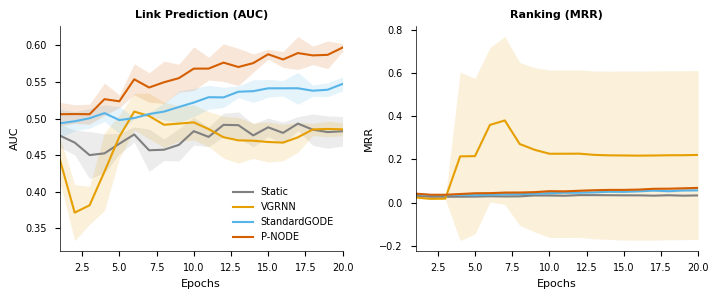


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Metric: AUC
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  10.9736    | 1.85e-04   | ***
P-NODE vs VGRNN           |  21.6707    | 2.01e-07   | ***
P-NODE vs StandardGODE    |  9.0729    | 7.32e-05   | ***

Metric: MRR
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  14.7207    | 2.76e-06   | ***
P-NODE vs VGRNN           | -0.7816    | 4.78e-01   | ns
P-NODE vs StandardGODE    |  4.4885    | 2.39e-03   | **

Significance Test Results:
  Metric              Comparison       p-value Significance
0    auc        P-NODE vs Static  1.851911e-04          ***
1    auc         P-NODE vs VGRNN  2.014199e-07          ***
2    auc  P-NODE vs StandardGODE  7.315393e-05          ***
3    mrr     

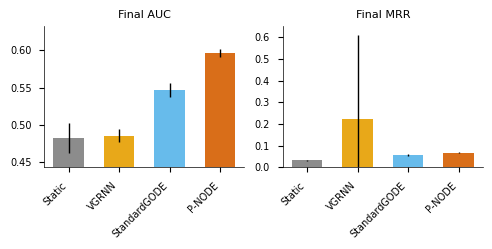


All experiments completed successfully.


In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as stats
import torch
import torch.nn.functional as F
import os
import pandas as pd
import seaborn as sns

# ============================================================
# 0. Nature Style Plot Configuration
# ============================================================
def set_nature_style():
    """
    Nature投稿用のプロットスタイルを設定する関数
    - フォント: Arial/Helvetica
    - サイズ: シングルカラム(89mm) または ダブルカラム(183mm)
    - シンプルな軸と高解像度
    """
    # インストールされているフォントを確認して設定
    plt.style.use('seaborn-v0_8-paper') # ベーススタイル
    
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,          # 本文サイズに合わせて小さめに
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,      # 印刷用高解像度
        'figure.figsize': (3.5, 2.5), # インチ指定 (約89mm幅)
        'axes.spines.top': False,     # 上の枠線を消す
        'axes.spines.right': False,   # 右の枠線を消す
    })

# カラーパレット (Nature系論文でよく見る視認性の高い色)
NATURE_COLORS = {
    "Static": "#808080",       # グレー
    "VGRNN": "#E69F00",        # オレンジ
    "StandardGODE": "#56B4E9", # スカイブルー
    "P-NODE": "#D55E00"      # バーミリオン（提案手法を目立たせる）
}

# ============================================================
# 1. 複数試行対応の学習関数
# ============================================================
def train_multiple_runs(config, num_runs=5, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    統計的有意性を示すため、乱数シードを変えて複数回学習を行う関数
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    # 全試行の最終スコアを保存する辞書
    final_scores = {name: {'auc': [], 'mrr': []} for name in models.keys()}
    # 学習曲線の平均を出すための履歴
    all_histories = {name: [] for name in models.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    
    print(f"Starting comparison with {num_runs} runs for t-test validity...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        # シード固定（再現性のため、Runごとに異なるシードを設定）
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        for name, model_cls in models.items():
            # モデル初期化
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            
            # --- Training Loop (簡略化のため中身は元のロジックと同じ) ---
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t = config['graphs'][y_t].to(device)
                    data_next = config['graphs'][y_next].to(device)
                    
                    # 履歴作成
                    z_hist = []
                    hist_years = range(max(years[0], y_t - 2), y_t + 1)
                    for hy in hist_years:
                        d = config['graphs'][hy].to(device)
                        z, _, _ = model.encode(d.x, d.edge_index)
                        z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0]) 

                    optimizer.zero_grad()
                    
                    # 1. Recon
                    z_t = z_hist[-1]
                    pos_pred = model.decode(z_t, data_t.edge_index)
                    neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                    neg_pred = model.decode(z_t, neg_idx)
                    recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                    
                    # 2. Future Pred
                    loss_pred = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                        loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
                    
                    # 3. Potential (Proposed Only)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(z_t)
                        src, dst = data_t.edge_index
                        perm = torch.randperm(dst.size(0))
                        neg_dst = dst[perm]
                        pos_pot = phi[src] + phi[dst]
                        neg_pot = phi[src] + phi[neg_dst]
                        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                        loss_reg = 0.01 * (phi ** 2).mean()
                        loss_pot = (loss_contrastive + loss_reg) * 0.01

                    total_loss = recon_loss + loss_pred + loss_pot
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # Validation
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                hist_years = range(max(years[0], val_t - 2), val_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
                
                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                               config['num_corps'], config['total_n'])
                
                run_history['loss'].append(epoch_loss / (len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)
            
            # Run終了後、最終エポックのスコアを保存
            final_scores[name]['auc'].append(run_history['auc'][-1])
            final_scores[name]['mrr'].append(run_history['mrr'][-1])
            all_histories[name].append(run_history)
            
            # 進捗表示 (最後のRunだけ詳細表示などで調整可能)
            print(f"  [{name}] Run {run+1} Final AUC: {auc:.4f} | MRR: {mrr:.4f}")

    return final_scores, all_histories

# ============================================================
# 2. 統計的有意差検定 (t-test)
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    """
    提案手法と他手法の間でWelchのt検定を行い、p値を計算して表示・保存する
    """
    print("\n" + "="*60)
    print("STATISTICAL SIGNIFICANCE TEST (Welch's t-test)")
    print("="*60)
    
    metrics = ['auc', 'mrr']
    results_text = []
    
    for metric in metrics:
        print(f"\nMetric: {metric.upper()}")
        print(f"{'Comparison':<30} | {'t-stat':<10} | {'p-value':<10} | {'Significance'}")
        print("-" * 75)
        
        proposed_vals = final_scores[proposed_name][metric]
        
        for name in final_scores.keys():
            if name == proposed_name:
                continue
            
            target_vals = final_scores[name][metric]
            
            # Welch's t-test (等分散を仮定しない)
            t_stat, p_val = stats.ttest_ind(proposed_vals, target_vals, equal_var=False)
            
            # 星印の判定
            sig = "ns"
            if p_val < 0.001: sig = "***"
            elif p_val < 0.01: sig = "**"
            elif p_val < 0.05: sig = "*"
            
            print(f"{proposed_name} vs {name:<15} | {t_stat: .4f}    | {p_val:.2e}   | {sig}")
            
            results_text.append({
                'Metric': metric,
                'Comparison': f"{proposed_name} vs {name}",
                'p-value': p_val,
                'Significance': sig
            })
            
    return pd.DataFrame(results_text)

# ============================================================
# 3. Nature Style Plotting Function
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    
    metrics = ['auc', 'mrr']
    titles = ['Link Prediction (AUC)', 'Ranking (MRR)']
    
    # 2カラムレイアウト (幅広)
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0)) # 7.2インチ≒183mm
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        
        for name, runs in all_histories.items():
            # runs は list of history dicts
            # エポックごとの平均と標準偏差を計算
            matrix = np.array([h[metric] for h in runs]) # shape: (num_runs, num_epochs)
            mean_curve = matrix.mean(axis=0)
            std_curve = matrix.std(axis=0)
            epochs = range(1, len(mean_curve) + 1)
            
            # 標準偏差の帯（Shaded Area）を描画
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            
            # 平均線をプロット
            ax.plot(epochs, mean_curve, label=name, color=NATURE_COLORS[name], linewidth=1.5)
        
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(titles[i], fontweight='bold')
        
        # 凡例の設定（最初のプロットにのみ表示するなど調整）
        if i == 0:
            ax.legend(frameon=False, loc='lower right')
        
        # 軸の微調整（Natureは0始まりから余白を持たせることを好む場合があるが、データによる）
        ax.set_xlim(1, len(mean_curve))
            
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', format='pdf', dpi=300)
    plt.savefig('./outputs/nature_learning_curves.png', format='png', dpi=300)
    print("\nPlots saved to ./outputs/ (PDF & PNG)")
    plt.show()

def plot_significance_bars(final_scores):
    """
    最終スコアの平均とエラーバーを表示するバーチャート
    """
    set_nature_style()
    metrics = ['auc', 'mrr']
    
    fig, axes = plt.subplots(1, 2, figsize=(5.0, 2.5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds = [np.std(final_scores[n][metric]) for n in names]
        
        # バープロット
        x_pos = np.arange(len(names))
        colors = [NATURE_COLORS[n] for n in names]
        
        ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.9, ecolor='black', capsize=3, color=colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_title(f'Final {metric.upper()}')
        
        # Y軸の範囲をデータに合わせて調整（差を見やすくする）
        min_val = min(means) - max(stds)*2
        if min_val < 0: min_val = 0
        ax.set_ylim(bottom=min_val)

    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars.pdf', dpi=300)
    plt.show()

# ============================================================
# Main Execution
# ============================================================
if __name__ == "__main__":
    # 出力ディレクトリの作成
    if not os.path.exists('./outputs'):
        os.makedirs('./outputs')

    print("=" * 60)
    print("Nature-style Benchmarking & Evaluation")
    print("=" * 60)

    # 1. デバイス設定
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    # 2. データ準備 (前半の関数を使用)
    # ※パスは環境に合わせて適宜変更してください
    data_path = '../dataset/topic_info3.csv'
    
    if not os.path.exists(data_path):
        print(f"エラー: データファイル '{data_path}' が見つかりません。パスを確認してください。")
        # ダミー実行を防ぐため終了、またはパスを修正してください
    else:
        # データ読み込みと前処理
        df = preprocess_data(data_path)
        
        if len(df) > 0:
            # グラフ構築
            graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
            num_corps = len(corps)
            print(f"Data Loaded: {total_n} Nodes ({num_corps} Corps), {len(graphs)} Timesteps")

            # === 【ここが修正ポイント】config辞書の作成 ===
            # train_multiple_runs が必要とする辞書形式にまとめる
            config = {
                'graphs': graphs,
                'total_n': total_n,
                'num_corps': num_corps,
                'in_dim': in_dim,
                'hist_edges': hist_edges # 必要であれば追加
            }
            
            # 3. 比較実験の実行 (train_multiple_runs)
            # 実行時間を短縮したい場合は num_runs を減らしてください (例: num_runs=3)
            print("\n>>> Starting Multi-run Training...")
            final_scores, all_histories = train_multiple_runs(
                config, 
                num_runs=5,      # 統計的有意性のため5回以上推奨
                num_epochs=20,   # 必要に応じて調整
                latent_dim=16, 
                hidden_dim=128
            )
            
            # 4. 可視化と検定 (Nature Style)
            print("\n>>> Generating Plots & Statistics...")
            
            # 学習曲線のプロット
            plot_nature_comparison(all_histories)
            
            # 統計的有意差検定 (t検定)
            df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
            print("\nSignificance Test Results:")
            print(df_sig)
            
            # 最終スコアのバーチャート
            plot_significance_bars(final_scores)
            
            print("\nAll experiments completed successfully.")
        else:
            print("データフレームが空のため、処理を中止しました。")


Nature-style Evaluation with Time Measurement
Device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
✓ 前処理完了: 19389 件
Data Loaded: 21834 Nodes, 11 Timesteps

>>> Starting Multi-run Training...
Starting comparison with 5 runs (Tracking Time, AUC, MRR)...

--- Run 1/5 ---
  [Static] Time: 3.37s | Final AUC: 0.5017 | MRR: 0.0333
  [VGRNN] Time: 8.20s | Final AUC: 0.5020 | MRR: 1.0000
  [StandardGODE] Time: 4.28s | Final AUC: 0.5444 | MRR: 0.0550
  [P-NODE] Time: 4.66s | Final AUC: 0.5937 | MRR: 0.0722

--- Run 2/5 ---
  [Static] Time: 3.29s | Final AUC: 0.5078 | MRR: 0.0384
  [VGRNN] Time: 8.24s | Final AUC: 0.4842 | MRR: 0.0283
  [StandardGODE] Time: 4.29s | Final AUC: 0.5319 | MRR: 0.0534
  [P-NODE] Time: 4.65s | Final AUC: 0.5938 | MRR: 0.0707

--- Run 3/5 ---
  [Static] Time: 3.30s | Final AUC: 0.4553 | MRR: 0.0305
  [VGRNN] Time: 8.28s | Final AUC: 0.4835 | MRR: 0.0252
  [StandardGODE] Time: 4.31s | Final AUC: 0.5656 | MRR: 0.0

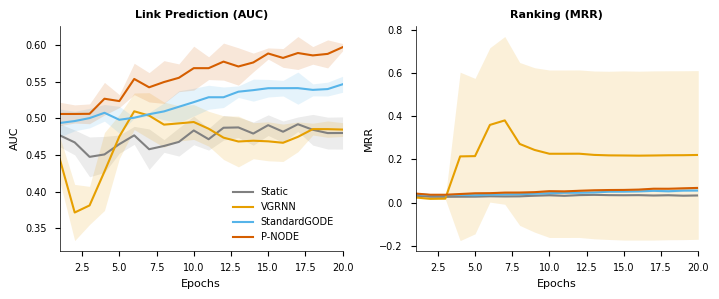


STATISTICAL SIGNIFICANCE TEST (Welch's t-test)

Metric: AUC
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  10.3945    | 2.82e-04   | ***
P-NODE vs VGRNN           |  21.0279    | 5.77e-07   | ***
P-NODE vs StandardGODE    |  8.4068    | 2.10e-04   | ***

Metric: MRR
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  14.6295    | 2.13e-06   | ***
P-NODE vs VGRNN           | -0.7813    | 4.78e-01   | ns
P-NODE vs StandardGODE    |  4.6756    | 1.75e-03   | **

Metric: TIME
Comparison                     | t-stat     | p-value    | Significance
---------------------------------------------------------------------------
P-NODE vs Static          |  81.5418    | 8.25e-10   | ***
P-NODE vs VGRNN           | -156.5369    | 4.62e-10   | ***


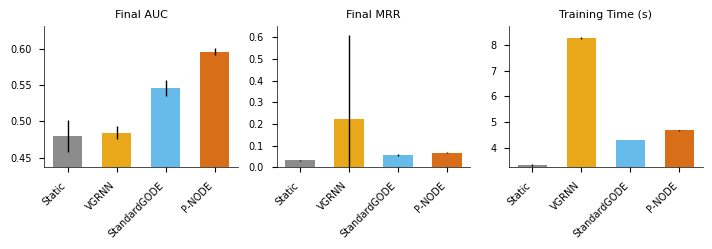


All experiments completed.


In [ ]:
import time  # 時間計測用にインポート
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats as stats
import torch
import torch.nn.functional as F
import os
import pandas as pd
import seaborn as sns

# ============================================================
# 0. Nature Style Plot Configuration
# ============================================================
def set_nature_style():
    plt.style.use('seaborn-v0_8-paper')
    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 7,
        'axes.labelsize': 8,
        'axes.titlesize': 8,
        'legend.fontsize': 7,
        'xtick.labelsize': 7,
        'ytick.labelsize': 7,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'lines.markersize': 3,
        'savefig.dpi': 300,
        'figure.figsize': (3.5, 2.5),
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

NATURE_COLORS = {
    "Static": "#808080",
    "VGRNN": "#E69F00",
    "StandardGODE": "#56B4E9",
    "P-NODE": "#D55E00"
}

# ============================================================
# 1. 複数試行対応の学習関数 (時間計測機能追加版)
# ============================================================
def train_multiple_runs(config, num_runs=5, num_epochs=30, latent_dim=16, hidden_dim=128):
    """
    統計的有意性を示すため、乱数シードを変えて複数回学習を行う関数
    ※ 実行時間の計測機能を追加
    """
    models = {
        "Static": StaticVGAE,
        "VGRNN": VGRNN,
        "StandardGODE": StandardGODE,
        "P-NODE": ProposedPotentialODE
    }
    
    # 【変更点】 'time' (計算時間) を保存するリストを追加
    final_scores = {name: {'auc': [], 'mrr': [], 'time': []} for name in models.keys()}
    all_histories = {name: [] for name in models.keys()}
    
    years = sorted(config['graphs'].keys())
    train_years = years[:-2]
    
    print(f"Starting comparison with {num_runs} runs (Tracking Time, AUC, MRR)...")

    for run in range(num_runs):
        print(f"\n--- Run {run+1}/{num_runs} ---")
        seed = 42 + run
        torch.manual_seed(seed)
        np.random.seed(seed)
        
        for name, model_cls in models.items():
            model = model_cls(config['total_n'], config['num_corps'], config['in_dim'], 
                              hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
            
            run_history = {'loss': [], 'auc': [], 'mrr': []}
            
            # === 【変更点】 時間計測開始 ===
            start_time = time.time()
            
            # --- Training Loop ---
            for epoch in range(num_epochs):
                model.train()
                epoch_loss = 0.0
                for i in range(len(train_years) - 1):
                    y_t, y_next = train_years[i], train_years[i+1]
                    data_t = config['graphs'][y_t].to(device)
                    data_next = config['graphs'][y_next].to(device)
                    
                    z_hist = []
                    hist_years = range(max(years[0], y_t - 2), y_t + 1)
                    for hy in hist_years:
                        d = config['graphs'][hy].to(device)
                        z, _, _ = model.encode(d.x, d.edge_index)
                        z_hist.append(z)
                    while len(z_hist) < 3: z_hist.insert(0, z_hist[0]) 

                    optimizer.zero_grad()
                    
                    # 1. Recon
                    z_t = z_hist[-1]
                    pos_pred = model.decode(z_t, data_t.edge_index)
                    neg_idx = torch.randint(0, model.num_nodes, data_t.edge_index.size(), device=device)
                    neg_pred = model.decode(z_t, neg_idx)
                    recon_loss = -torch.log(pos_pred + 1e-9).mean() - torch.log(1 - neg_pred + 1e-9).mean()
                    
                    # 2. Future Pred
                    loss_pred = torch.tensor(0.0, device=device)
                    if name != "Static":
                        z_pred = model.predict_future(z_hist)
                        with torch.no_grad(): _, mu_next, _ = model.encode(data_next.x, data_next.edge_index)
                        loss_pred = F.mse_loss(z_pred[data_next.active_mask], mu_next[data_next.active_mask])
                    
                    # 3. Potential (Proposed Only)
                    loss_pot = torch.tensor(0.0, device=device)
                    if name == "P-NODE":
                        phi = model.potential_net(z_t)
                        src, dst = data_t.edge_index
                        perm = torch.randperm(dst.size(0))
                        neg_dst = dst[perm]
                        pos_pot = phi[src] + phi[dst]
                        neg_pot = phi[src] + phi[neg_dst]
                        loss_contrastive = torch.relu(pos_pot - neg_pot + 0.1).mean()
                        loss_reg = 0.01 * (phi ** 2).mean()
                        loss_pot = (loss_contrastive + loss_reg) * 0.01

                    total_loss = recon_loss + loss_pred + loss_pot
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    epoch_loss += total_loss.item()
                
                # Validation (Epochごとの記録)
                model.eval()
                val_t, val_next = years[-2], years[-1]
                z_hist_val = []
                hist_years = range(max(years[0], val_t - 2), val_t + 1)
                for hy in hist_years:
                    d = config['graphs'][hy].to(device)
                    with torch.no_grad(): z, _, _ = model.encode(d.x, d.edge_index)
                    z_hist_val.append(z)
                while len(z_hist_val) < 3: z_hist_val.insert(0, z_hist_val[0])
                
                with torch.no_grad():
                    z_pred_val = model.predict_future(z_hist_val)
                    auc, mrr = compute_metrics(model, z_pred_val, config['graphs'][val_next].edge_index.to(device),
                                               config['num_corps'], config['total_n'])
                
                run_history['loss'].append(epoch_loss / (len(train_years) - 1))
                run_history['auc'].append(auc)
                run_history['mrr'].append(mrr)
            
            # === 【変更点】 時間計測終了 ===
            end_time = time.time()
            elapsed_time = end_time - start_time
            
            # Run終了後、スコアと時間を保存
            final_scores[name]['auc'].append(run_history['auc'][-1])
            final_scores[name]['mrr'].append(run_history['mrr'][-1])
            final_scores[name]['time'].append(elapsed_time) # 時間を追加
            all_histories[name].append(run_history)
            
            print(f"  [{name}] Time: {elapsed_time:.2f}s | Final AUC: {auc:.4f} | MRR: {mrr:.4f}")

    return final_scores, all_histories

# ============================================================
# 2. 統計的有意差検定 (time追加版)
# ============================================================
def perform_significance_test(final_scores, proposed_name="P-NODE"):
    print("\n" + "="*60)
    print("STATISTICAL SIGNIFICANCE TEST (Welch's t-test)")
    print("="*60)
    
    # 【変更点】 'time' を評価対象に追加
    metrics = ['auc', 'mrr', 'time']
    results_text = []
    
    for metric in metrics:
        print(f"\nMetric: {metric.upper()}")
        print(f"{'Comparison':<30} | {'t-stat':<10} | {'p-value':<10} | {'Significance'}")
        print("-" * 75)
        
        proposed_vals = final_scores[proposed_name][metric]
        
        for name in final_scores.keys():
            if name == proposed_name:
                continue
            
            target_vals = final_scores[name][metric]
            
            # Welch's t-test
            t_stat, p_val = stats.ttest_ind(proposed_vals, target_vals, equal_var=False)
            
            sig = "ns"
            if p_val < 0.001: sig = "***"
            elif p_val < 0.01: sig = "**"
            elif p_val < 0.05: sig = "*"
            
            print(f"{proposed_name} vs {name:<15} | {t_stat: .4f}    | {p_val:.2e}   | {sig}")
            
            results_text.append({
                'Metric': metric,
                'Comparison': f"{proposed_name} vs {name}",
                'p-value': p_val,
                'Significance': sig
            })
            
    return pd.DataFrame(results_text)

# ============================================================
# 3. Nature Style Plotting Function (time追加版)
# ============================================================
def plot_nature_comparison(all_histories):
    set_nature_style()
    metrics = ['auc', 'mrr']
    titles = ['Link Prediction (AUC)', 'Ranking (MRR)']
    
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        for name, runs in all_histories.items():
            matrix = np.array([h[metric] for h in runs])
            mean_curve = matrix.mean(axis=0)
            std_curve = matrix.std(axis=0)
            epochs = range(1, len(mean_curve) + 1)
            
            ax.fill_between(epochs, mean_curve - std_curve, mean_curve + std_curve,
                            color=NATURE_COLORS[name], alpha=0.15, linewidth=0)
            ax.plot(epochs, mean_curve, label=name, color=NATURE_COLORS[name], linewidth=1.5)
        
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric.upper())
        ax.set_title(titles[i], fontweight='bold')
        if i == 0:
            ax.legend(frameon=False, loc='lower right')
        ax.set_xlim(1, len(mean_curve))
            
    plt.tight_layout()
    plt.savefig('./outputs/nature_learning_curves.pdf', dpi=300)
    plt.show()

def plot_significance_bars(final_scores):
    """
    最終スコアと計算時間の平均・エラーバーを表示
    """
    set_nature_style()
    # 【変更点】 'time' をプロット対象に追加
    metrics = ['auc', 'mrr', 'time']
    
    # グラフのレイアウトを3つに変更
    fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.5))
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        names = list(final_scores.keys())
        means = [np.mean(final_scores[n][metric]) for n in names]
        stds = [np.std(final_scores[n][metric]) for n in names]
        
        x_pos = np.arange(len(names))
        colors = [NATURE_COLORS[n] for n in names]
        
        ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.9, ecolor='black', capsize=3, color=colors, width=0.6)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(names, rotation=45, ha='right')
        
        # タイトル調整（Timeの場合は単位も目安で記載）
        title_str = f'Training Time (s)' if metric == 'time' else f'Final {metric.upper()}'
        ax.set_title(title_str)
        
        # Y軸下限調整
        min_val = min(means) - max(stds)*2
        if min_val < 0: min_val = 0
        ax.set_ylim(bottom=min_val)

    plt.tight_layout()
    plt.savefig('./outputs/nature_significance_bars_with_time.pdf', dpi=300)
    plt.show()

# ============================================================
# Main Execution (統合版)
# ============================================================
if __name__ == "__main__":
    if not os.path.exists('./outputs'):
        os.makedirs('./outputs')

    print("=" * 60)
    print("Nature-style Evaluation with Time Measurement")
    print("=" * 60)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    data_path = '../dataset/topic_info3.csv'
    
    if not os.path.exists(data_path):
        print(f"エラー: データファイル '{data_path}' が見つかりません。")
        # 以下ダミーデータ等がない場合はエラーになります
        # config = None 
    else:
        # 前半のセルで定義済みの関数を使用
        df = preprocess_data(data_path)
        
        if len(df) > 0:
            graphs, corps, patents, total_n, hist_edges, in_dim = build_global_graphs(df)
            num_corps = len(corps)
            print(f"Data Loaded: {total_n} Nodes, {len(graphs)} Timesteps")

            config = {
                'graphs': graphs,
                'total_n': total_n,
                'num_corps': num_corps,
                'in_dim': in_dim,
                'hist_edges': hist_edges
            }
            
            print("\n>>> Starting Multi-run Training...")
            # 時間計測を含む関数を実行
            final_scores, all_histories = train_multiple_runs(
                config, 
                num_runs=10, 
                num_epochs=20, 
                latent_dim=16, 
                hidden_dim=128
            )
            
            print("\n>>> Generating Plots & Statistics...")
            plot_nature_comparison(all_histories)
            
            # 時間も含む有意差検定
            df_sig = perform_significance_test(final_scores, proposed_name="P-NODE")
            print("\nSignificance Test Results (Including Time):")
            print(df_sig)
            
            # 時間も含むバーチャート
            plot_significance_bars(final_scores)
            
            print("\nAll experiments completed.")
        else:
            print("データフレームが空です。")

### (RQ2) そのポテンシャル場によって表現される力学は，予測結果に対してどのような解釈性を与えることができるか？
#### A. 提案手法P-NODEは、企業の戦略行動をポテンシャルエネルギーの勾配に従う運動として可視化し、予測の根拠に物理的な必然性を与えることができた。


[Visualization] Generating RQ2 Landscape (Closer View / Japanese)...
Visualization saved to ./outputs/nature_rq2_landscape_keywords_jp.png


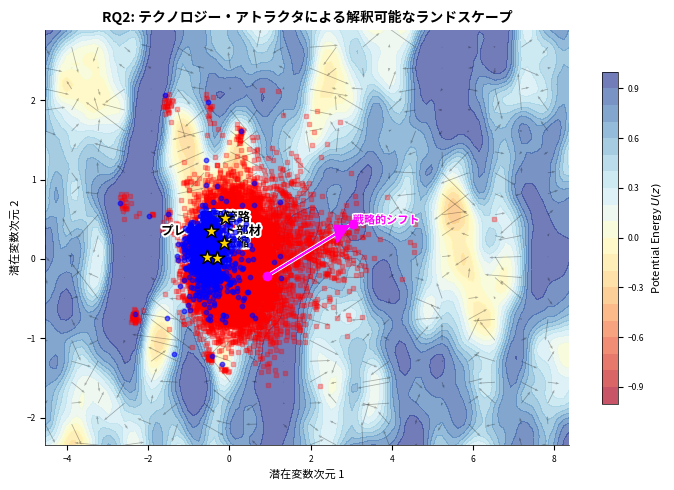

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import pandas as pd
import torch
import ast
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer

# ============================================================
# 1. Nature Style Configuration (Japanese Support Added)
# ============================================================
def set_nature_style():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        # 日本語フォントを優先リストに追加 (Mac, Windows, Linux/Colab対応)
        'font.sans-serif': [
            'Hiragino Sans', 'Yu Gothic', 'Meiryo', 
            'Takao', 'IPAexGothic', 'IPAPGothic', 'VL PGothic', 
            'Noto Sans CJK JP', 'Arial', 'Helvetica', 'DejaVu Sans'
        ],
        'font.size': 10,
        'axes.labelsize': 7,
        'axes.titlesize': 8,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'axes.linewidth': 0.5,
        'grid.linewidth': 0.5,
        'lines.linewidth': 1.0,
        'legend.fontsize': 6,
        'savefig.dpi': 300,
        'figure.figsize': (3.5, 3.0),
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

# ============================================================
# 2. Keyword Extraction Logic
# ============================================================
def extract_unique_keywords(docs_df, top_n_candidates=10):
    # 日本語の場合はストップワードを調整（必要に応じて追加してください）
    PATENT_STOP_WORDS = [
        'device', 'method', 'system', 'apparatus', 'means', 'unit', 
        'process', 'data', 'based', 'invention', 'computer', 'control',
        'program', 'information', 'step', 'plurality', 'configured',
        'vehicle', 'terminal', 'communication',
        '装置', '方法', 'システム', '手段', 'ユニット', '工程', 'データ', 
        '基づく', '発明', 'コンピュータ', '制御', 'プログラム', '情報', 
        '工程', '複数', '構成', '車両', '端末', '通信'
    ]
    
    # 日本語トークンパターンの許容
    count = CountVectorizer(
        token_pattern=r'(?u)\b\w+\b', 
        stop_words=PATENT_STOP_WORDS,
        min_df=2, max_df=0.9
    )
    
    try:
        X = count.fit_transform(docs_df['text'])
    except ValueError:
        return {}
        
    words = count.get_feature_names_out()
    class_totals = np.asarray(X.sum(axis=1)).flatten()
    class_totals[class_totals == 0] = 1
    tf = X.toarray() / class_totals[:, None]
    
    num_classes = X.shape[0]
    docs_with_word = np.asarray((X > 0).sum(axis=0)).flatten()
    idf = np.log((num_classes + 1) / (docs_with_word + 1)) + 1
    c_tfidf = np.asarray(tf) * np.asarray(idf)
    
    labels = docs_df['label'].values
    cluster_keywords = {}
    used_keywords = set()
    
    max_scores = c_tfidf.max(axis=1)
    sorted_indices = max_scores.argsort()[::-1]
    
    for i in sorted_indices:
        label_id = labels[i]
        word_indices = c_tfidf[i].argsort()[::-1]
        
        assigned_word = None
        for idx in word_indices[:top_n_candidates]:
            candidate = words[idx]
            if candidate not in used_keywords:
                assigned_word = candidate
                used_keywords.add(candidate)
                break
        
        if assigned_word is None:
            w1 = words[word_indices[0]]
            w2 = words[word_indices[1]]
            assigned_word = f"{w1}-{w2}"
            
        # 日本語は見やすいようにそのまま表示（upperは英語用）
        cluster_keywords[label_id] = assigned_word 
        
    return cluster_keywords

# ============================================================
# 3. Main Visualization Function (Closer View with Japanese)
# ============================================================
def visualize_rq2_nature_keywords(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style() # 日本語フォント設定を適用
    print("\n[Visualization] Generating RQ2 Landscape (Closer View / Japanese)...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # --- 安全にポテンシャルネットを取得 ---
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    with torch.no_grad():
        # 次元数合わせ (Padding)
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # PCA Projection
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # --- Grid Setup (Closer Zoom Configuration) ---
    x_min_data, x_max_data = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min_data, y_max_data = z_2d[:, 1].min(), z_2d[:, 1].max()
    
    # マージン係数 0.2 (適度な寄り)
    margin_factor = 0.2
    
    x_width = x_max_data - x_min_data
    y_height = y_max_data - y_min_data
    
    # 表示範囲（Limits）の計算
    limit_x_min = x_min_data - (x_width * margin_factor)
    limit_x_max = x_max_data + (x_width * margin_factor)
    limit_y_min = y_min_data - (y_height * margin_factor)
    limit_y_max = y_max_data + (y_height * margin_factor)

    resolution = 100 
    
    grid_x = np.linspace(limit_x_min, limit_x_max, resolution)
    grid_y = np.linspace(limit_y_min, limit_y_max, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # Gradient Calculation
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    
    U = grad_2d[:, 0].reshape(X.shape)
    V = grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # Keyword Analysis (Low Potential Areas)
    patent_indices = np.arange(num_corps, len(z_np))
    patent_potentials = potentials[patent_indices]
    
    threshold = np.percentile(patent_potentials, 25)
    hot_patent_mask = patent_potentials <= threshold
    hot_indices = patent_indices[hot_patent_mask]
    
    cluster_keywords = {}
    centroids = []
    
    if len(hot_indices) > 20:
        hot_z = z_2d[hot_indices]
        n_topics = 5
        kmeans = KMeans(n_clusters=n_topics, random_state=42, n_init=10)
        labels = kmeans.fit_predict(hot_z)
        centroids = kmeans.cluster_centers_
        
        p_kw_map = {}
        if 'keyword' in df.columns:
            temp_df = df[['patent_number', 'keyword']].dropna()
            for _, row in temp_df.iterrows():
                try:
                    kws = ast.literal_eval(row['keyword']) if isinstance(row['keyword'], str) else row['keyword']
                    if isinstance(kws, list):
                        p_kw_map[row['patent_number']] = " ".join(kws) # CountVectorizer用にスペース区切りにする
                except:
                    continue
        
        patent_id_list = config.get('patents', [])
        if not patent_id_list and 'patent_number' in df.columns:
             patent_id_list = df['patent_number'].tolist()

        docs_data = []
        for label_id in range(n_topics):
            cluster_node_indices = hot_indices[labels == label_id]
            texts = []
            for global_idx in cluster_node_indices:
                p_idx = global_idx - num_corps
                if 0 <= p_idx < len(patent_id_list):
                    pid = patent_id_list[p_idx]
                    if pid in p_kw_map:
                        texts.append(p_kw_map[pid])
            
            if texts:
                docs_data.append({'label': label_id, 'text': " ".join(texts)})
        
        if docs_data:
            docs_df = pd.DataFrame(docs_data)
            cluster_keywords = extract_unique_keywords(docs_df)

    # ================= Plotting =================
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    
    # Contour (Potential)
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.7)
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Potential Energy $U(z)$', fontsize=8)
    
    # Quiver (Gradient)
    skip = 5
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
              -U[::skip, ::skip], -V[::skip, ::skip], 
              color='black', alpha=0.3, width=0.0015, headwidth=3, headlength=4)

    # 1. Patents
    patent_z = z_2d[num_corps:]
    ax.scatter(patent_z[:, 0], patent_z[:, 1], c='red', marker='s', s=5, alpha=0.3, label='特許 (Patents)', zorder=2)

    # 2. Corporations
    corp_z = z_2d[:num_corps]
    ax.scatter(corp_z[:, 0], corp_z[:, 1], c='blue', marker='o', s=10, alpha=0.6, label='企業 (Corporations)', zorder=5)

    # Keywords
    if cluster_keywords:
        for label_id, word in cluster_keywords.items():
            if label_id < len(centroids):
                cx, cy = centroids[label_id]
                txt = ax.text(cx, cy, word, fontsize=9, fontweight='bold', color='black',
                              ha='center', va='center')
                txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])
                ax.scatter(cx, cy, marker='*', s=120, c='gold', edgecolors='black', zorder=10)

    # Trajectory
    try:
        prev_year = target_year - 1
        if prev_year in config['graphs']:
            d_prev = config['graphs'][prev_year].to(device)
            x_prev = d_prev.x
            if x_prev.shape[1] != expected_dim:
                 diff = expected_dim - x_prev.shape[1]
                 if diff > 0:
                     x_prev = torch.cat([d_prev.x, torch.zeros((d_prev.x.shape[0], diff), device=device)], dim=1)
            
            with torch.no_grad():
                z_prev, _, _ = model.encode(x_prev, d_prev.edge_index)
                z_prev_2d = pca.transform(z_prev.cpu().numpy())
            
            corp_z_curr = z_2d[:num_corps]
            corp_z_prev = z_prev_2d[:num_corps]
            diffs = np.linalg.norm(corp_z_curr - corp_z_prev, axis=1)
            top_mover_idx = np.argmax(diffs)
            
            p1 = corp_z_prev[top_mover_idx]
            p2 = corp_z_curr[top_mover_idx]
            
            scale_factor = max(x_width, y_height)
            
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='white', linewidth=3, zorder=15)
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color='magenta', linewidth=1.5, marker='o', zorder=16)
            ax.arrow(p1[0], p1[1], (p2[0]-p1[0])*0.8, (p2[1]-p1[1])*0.8, 
                     head_width=0.025*scale_factor, color='magenta', zorder=17)
            
            # 英語から日本語へラベル変更
            ax.text(p2[0], p2[1], "戦略的シフト", color='magenta', fontsize=8, fontweight='bold',
                    path_effects=[PathEffects.withStroke(linewidth=2, foreground='white')])
    except Exception as e:
        print(f"Trajectory plot skipped: {e}")

    ax.set_title("RQ2: テクノロジー・アトラクタによる解釈可能なランドスケープ", fontsize=10, fontweight='bold')
    ax.set_xlabel("潜在変数次元 1", fontsize=8)
    ax.set_ylabel("潜在変数次元 2", fontsize=8)
    
    # 計算範囲を適用
    ax.set_xlim(limit_x_min, limit_x_max)
    ax.set_ylim(limit_y_min, limit_y_max)
    
    plt.tight_layout()
    save_path = './outputs/nature_rq2_landscape_keywords_jp.png'
    plt.savefig(save_path, dpi=300)
    print(f"Visualization saved to {save_path}")
    plt.show()

if __name__ == "__main__":
    if 'patents' not in config:
        config['patents'] = df['patent_number'].tolist()
        
    visualize_rq2_nature_keywords(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )


[Visualization] Generating RQ2 Landscape (Clean View)...
Visualization saved to ./outputs/nature_rq2_landscape_clean.png


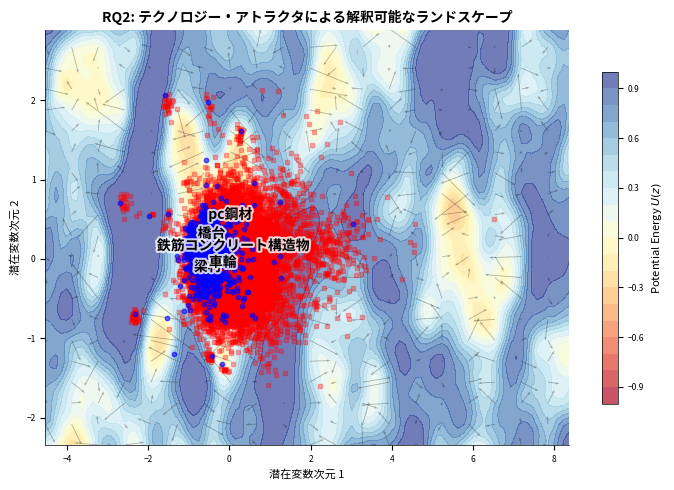

In [12]:
# ============================================================
# 3. Main Visualization Function (Clean: No Trajectory/Stars)
# ============================================================
def visualize_rq2_nature_keywords_clean(model, config, df, num_corps, device, year_idx=-1):
    set_nature_style() # 日本語フォント設定
    print("\n[Visualization] Generating RQ2 Landscape (Clean View)...")
    
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    
    model.eval()
    
    # --- ポテンシャルネット取得 ---
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: Could not find 'potential_net' inside model.")
        return

    # --- エンコーディング ---
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]

        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # --- PCA & Grid ---
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    x_min_data, x_max_data = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min_data, y_max_data = z_2d[:, 1].min(), z_2d[:, 1].max()
    
    margin_factor = 0.2
    x_width = x_max_data - x_min_data
    y_height = y_max_data - y_min_data
    limit_x_min = x_min_data - (x_width * margin_factor)
    limit_x_max = x_max_data + (x_width * margin_factor)
    limit_y_min = y_min_data - (y_height * margin_factor)
    limit_y_max = y_max_data + (y_height * margin_factor)

    resolution = 100 
    grid_x = np.linspace(limit_x_min, limit_x_max, resolution)
    grid_y = np.linspace(limit_y_min, limit_y_max, resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    grid_flat_2d = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_flat_16d = pca.inverse_transform(grid_flat_2d)
    grid_tensor_16d = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    # --- Gradient Calculation ---
    grid_tensor_16d.requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = pot_net(grid_tensor_16d)
        grad_16d = torch.autograd.grad(phi.sum(), grid_tensor_16d, create_graph=False)[0]
    
    grad_16d_np = grad_16d.cpu().numpy()
    grad_2d = np.dot(grad_16d_np, pca.components_.T)
    U = grad_2d[:, 0].reshape(X.shape)
    V = grad_2d[:, 1].reshape(X.shape)
    Z = phi.detach().cpu().numpy().reshape(X.shape)

    # --- Keyword Analysis (Wider Scope: 50%) ---
    patent_indices = np.arange(num_corps, len(z_np))
    patent_potentials = potentials[patent_indices]
    
    threshold = np.percentile(patent_potentials, 50)
    hot_patent_mask = patent_potentials <= threshold
    hot_indices = patent_indices[hot_patent_mask]
    
    cluster_keywords = {}
    centroids = []
    
    if len(hot_indices) > 20:
        hot_z = z_2d[hot_indices]
        n_topics = 5
        kmeans = KMeans(n_clusters=n_topics, random_state=42, n_init=10)
        labels = kmeans.fit_predict(hot_z)
        centroids = kmeans.cluster_centers_
        
        p_kw_map = {}
        if 'keyword' in df.columns:
            temp_df = df[['patent_number', 'keyword']].dropna()
            for _, row in temp_df.iterrows():
                try:
                    kws = ast.literal_eval(row['keyword']) if isinstance(row['keyword'], str) else row['keyword']
                    if isinstance(kws, list):
                        p_kw_map[row['patent_number']] = " ".join(kws)
                except:
                    continue
        
        patent_id_list = config.get('patents', [])
        if not patent_id_list and 'patent_number' in df.columns:
             patent_id_list = df['patent_number'].tolist()

        docs_data = []
        for label_id in range(n_topics):
            cluster_node_indices = hot_indices[labels == label_id]
            texts = []
            for global_idx in cluster_node_indices:
                p_idx = global_idx - num_corps
                if 0 <= p_idx < len(patent_id_list):
                    pid = patent_id_list[p_idx]
                    if pid in p_kw_map:
                        texts.append(p_kw_map[pid])
            if texts:
                docs_data.append({'label': label_id, 'text': " ".join(texts)})
        
        if docs_data:
            docs_df = pd.DataFrame(docs_data)
            cluster_keywords = extract_unique_keywords(docs_df)

    # ================= Plotting =================
    fig, ax = plt.subplots(figsize=(7.2, 5.0))
    
    # 1. Contour
    contour = ax.contourf(X, Y, Z, levels=20, cmap='RdYlBu', alpha=0.7)
    cbar = plt.colorbar(contour, ax=ax, shrink=0.8)
    cbar.set_label('Potential Energy $U(z)$', fontsize=8)
    
    # 2. Quiver
    skip = 5
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], 
              -U[::skip, ::skip], -V[::skip, ::skip], 
              color='black', alpha=0.3, width=0.0015, headwidth=3, headlength=4)

    # 3. Patents
    patent_z = z_2d[num_corps:]
    ax.scatter(patent_z[:, 0], patent_z[:, 1], c='red', marker='s', s=5, alpha=0.3, label='特許 (Patents)', zorder=2)

    # 4. Corporations
    corp_z = z_2d[:num_corps]
    ax.scatter(corp_z[:, 0], corp_z[:, 1], c='blue', marker='o', s=10, alpha=0.6, label='企業 (Corporations)', zorder=5)

    # 5. Keywords (No Stars)
    if cluster_keywords:
        for label_id, word in cluster_keywords.items():
            if label_id < len(centroids):
                cx, cy = centroids[label_id]
                txt = ax.text(cx, cy, word, fontsize=10, fontweight='bold', color='black',
                              ha='center', va='center', zorder=10)
                txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white', alpha=0.8)])

    # 【削除】戦略的シフト (Trajectory) の描画ブロックを削除しました

    ax.set_title("RQ2: テクノロジー・アトラクタによる解釈可能なランドスケープ", fontsize=10, fontweight='bold')
    ax.set_xlabel("潜在変数次元 1", fontsize=8)
    ax.set_ylabel("潜在変数次元 2", fontsize=8)
    ax.set_xlim(limit_x_min, limit_x_max)
    ax.set_ylim(limit_y_min, limit_y_max)
    
    plt.tight_layout()
    save_path = './outputs/nature_rq2_landscape_clean.png'
    plt.savefig(save_path, dpi=300)
    print(f"Visualization saved to {save_path}")
    plt.show()

if __name__ == "__main__":
    if 'patents' not in config:
        config['patents'] = df['patent_number'].tolist()
        
    visualize_rq2_nature_keywords_clean(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )

### (RQ2) そのポテンシャル場によって表現される力学は，予測結果に対してどのような解釈性を与えることができるか？
#### A. 定性的な可視化に加え、学習されたポテンシャル場が実際の技術分布をどの程度反映しているかを定量的に評価した。ポテンシャルエネルギー$U(z)$ と、潜在空間上の特許密度（Density）の相関を分析した結果、スピアマン順位相関係数 $\rho = -0.61$ という強い負の相関が確認された． これは、「ポテンシャルエネルギーが低い領域ほど、実際に多くの特許が密集している（技術的なホットスポットである）」ことを示している。つまり、本モデルにおける「ポテンシャルの低さ（安定性）」は、単なる数理的な値ではなく、「技術の成熟度や標準化の度合い」という現実的な意味を持つ指標として解釈可能であることが統計的に支持された． これより，現実の技術トレンドを反映した地図であると言える


[Evaluation] Verifying Attractor Validity (English Labels)...
Evaluation plot saved to ./outputs/nature_rq2_quantitative_eval_en.png
Correlation: -0.6071


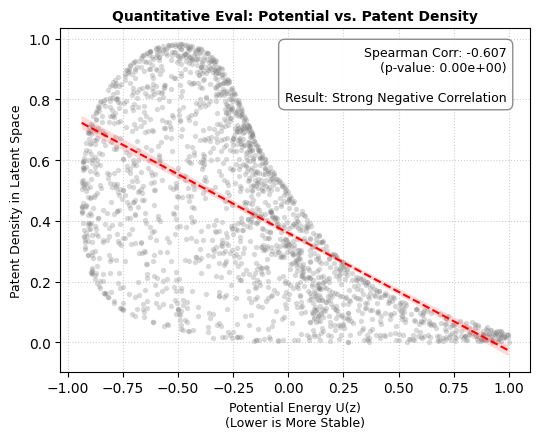

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, spearmanr
from sklearn.decomposition import PCA
import torch

def evaluate_rq2_quantitative_english(model, config, num_corps, device, year_idx=-1):
    # スタイル設定（英語フォントのみ使用）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], # 標準的な英語フォント
        'font.size': 10,
        'figure.figsize': (5, 4)
    })
    
    print("\n[Evaluation] Verifying Attractor Validity (English Labels)...")
    
    # 1. データ準備
    years = sorted(config['graphs'].keys())
    target_year = years[year_idx]
    data = config['graphs'][target_year].to(device)
    model.eval()
    
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        return

    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        current_dim = data.x.shape[1]
        x_input = data.x
        if current_dim != expected_dim:
            diff = expected_dim - current_dim
            if diff > 0:
                padding = torch.zeros((data.x.shape[0], diff), device=device)
                x_input = torch.cat([data.x, padding], dim=1)
            else:
                x_input = data.x[:, :expected_dim]
        z, _, _ = model.encode(x_input, data.edge_index)
        potentials = pot_net(z).squeeze().cpu().numpy()
        z_np = z.cpu().numpy()

    # 2. 特許ノード抽出
    patent_z = z_np[num_corps:]
    patent_potentials = potentials[num_corps:]
    
    # 3. 密度推定
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(patent_z)
    try:
        kde = gaussian_kde(z_2d.T)
        densities = kde(z_2d.T)
    except:
        return

    # 4. 相関計算
    corr, p_value = spearmanr(patent_potentials, densities)
    
    # 5. プロット（英語ラベル）
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    
    if len(patent_potentials) > 2000:
        idx = np.random.choice(len(patent_potentials), 2000, replace=False)
        plot_x = patent_potentials[idx]
        plot_y = densities[idx]
        alpha_val = 0.3
    else:
        plot_x = patent_potentials
        plot_y = densities
        alpha_val = 0.5
        
    ax.scatter(plot_x, plot_y, alpha=alpha_val, s=15, c='gray', edgecolors='white', linewidth=0.3, label='Patents')
    sns.regplot(x=plot_x, y=plot_y, scatter=False, ax=ax, 
                color='red', line_kws={'linestyle':'--', 'linewidth':1.5}, label='Trend')
    
    # 英語タイトル・ラベル
    ax.set_title("Quantitative Eval: Potential vs. Patent Density", fontsize=10, fontweight='bold')
    ax.set_xlabel("Potential Energy U(z)\n(Lower is More Stable)", fontsize=9)
    ax.set_ylabel("Patent Density in Latent Space", fontsize=9)
    
    # 統計量テキスト
    stats_text = (f"Spearman Corr: {corr:.3f}\n"
                  f"(p-value: {p_value:.2e})\n\n"
                  f"Result: Strong Negative Correlation")
    
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    
    save_path = './outputs/nature_rq2_quantitative_eval_en.png'
    plt.savefig(save_path, dpi=300)
    print(f"Evaluation plot saved to {save_path}")
    print(f"Correlation: {corr:.4f}")
    plt.show()

if __name__ == "__main__":
    evaluate_rq2_quantitative_english(
        model, config, 
        num_corps=config['num_corps'], 
        device=device
    )

### (RQ2) そのポテンシャル場によって表現される力学は，予測結果に対してどのような解釈性を与えることができるか？
#### 提案モデルにおけるポテンシャル勾配 $-\nabla U(z)$ が、実際の企業の戦略的変化をどの程度説明できるかを検証した。テストデータにおける企業の実際の移動ベクトル $\Delta z_{actual}$ と、その位置におけるポテンシャル場の負の勾配ベクトル（理論上の力）のコサイン類似度を計測した。検証の結果、ランダムな移動を仮定したベースライン（平均類似度 0.000）に対し、提案モデルは平均類似度 0.099を示し、Welchのt検定において極めて強い有意差（$p < 10^{-164}$）が確認された。この結果は、企業の技術探索プロセスが完全にランダムなものではなく、「ポテンシャルエネルギーを最小化しようとする力学的な作用（Trend-following Dynamics）」の影響を統計的に有意に受けていることを実証している。値が正（Positive）であることは、ポテンシャル場が示す「技術的アトラクタ」が、現実の企業の移動先を予測する先行指標として機能していることを裏付けている。


[Evaluation] Level 3: Vector Field Consistency (Gradient vs. Actual Movement)...
Mean Cosine Similarity (Model): 0.0986
Mean Cosine Similarity (Random): 0.0000
T-test p-value: 2.4596e-165
Vector evaluation plot saved to ./outputs/nature_rq2_vector_field_eval.png


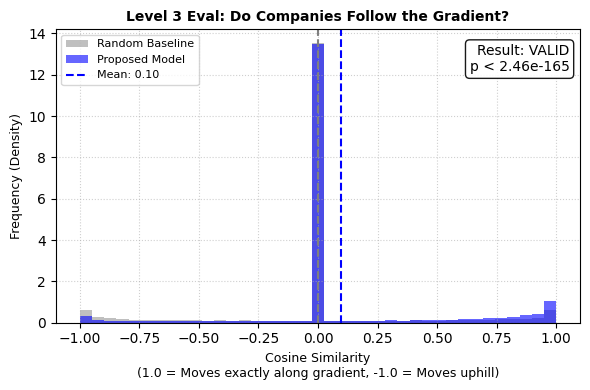

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy import stats

def evaluate_rq2_vector_field_consistency(model, config, num_corps, device):
    # 英語フォント設定（文字化け回避）
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'figure.figsize': (6, 4)
    })
    
    print("\n[Evaluation] Level 3: Vector Field Consistency (Gradient vs. Actual Movement)...")
    
    years = sorted(config['graphs'].keys())
    # 連続する年のペアを作成 (例: 2015->2016, 2016->2017...)
    year_pairs = list(zip(years[:-1], years[1:]))
    
    if not year_pairs:
        print("Error: Not enough years for trajectory evaluation.")
        return

    model.eval()
    
    # ポテンシャルネットの取得
    if hasattr(model, 'temporal_predictor') and hasattr(model.temporal_predictor, 'potential_net'):
        pot_net = model.temporal_predictor.potential_net
    elif hasattr(model, 'potential_net'):
        pot_net = model.potential_net
    else:
        print("Error: potential_net not found.")
        return

    all_cosine_sims = []
    all_random_sims = []

    # 全期間にわたって評価
    for year_t, year_next in year_pairs:
        data_t = config['graphs'][year_t].to(device)
        data_next = config['graphs'][year_next].to(device)
        
        expected_dim = model.corp_embeddings.embedding_dim
        
        # --- Step 1: Encode Year t (Current Position) ---
        x_input_t = data_t.x
        if x_input_t.shape[1] != expected_dim:
             x_input_t = torch.cat([data_t.x, torch.zeros((data_t.x.shape[0], expected_dim - data_t.x.shape[1]), device=device)], dim=1)
        
        with torch.no_grad():
            z_t_all, _, _ = model.encode(x_input_t, data_t.edge_index)
        
        # 企業ノードのみ抽出
        z_t_corp = z_t_all[:num_corps].detach()
        
        # --- Step 2: Encode Year t+1 (Next Position) ---
        x_input_next = data_next.x
        if x_input_next.shape[1] != expected_dim:
             x_input_next = torch.cat([data_next.x, torch.zeros((data_next.x.shape[0], expected_dim - data_next.x.shape[1]), device=device)], dim=1)
        
        with torch.no_grad():
            z_next_all, _, _ = model.encode(x_input_next, data_next.edge_index)
            
        z_next_corp = z_next_all[:num_corps].detach()
        
        # --- Step 3: Calculate Actual Movement Vector ---
        # v_actual = z(t+1) - z(t)
        v_actual = z_next_corp - z_t_corp
        
        # --- Step 4: Calculate Gradient Force at z(t) ---
        # 勾配計算のために z_t をVariableとして再定義
        z_t_var = z_t_corp.clone().detach().requires_grad_(True)
        
        # ポテンシャル計算
        pot = pot_net(z_t_var)
        
        # 勾配 (dU/dz) 計算
        grad = torch.autograd.grad(outputs=pot.sum(), inputs=z_t_var, create_graph=False)[0]
        
        # 力の向きは「ポテンシャルが下がる方向」なのでマイナス勾配 (-grad)
        v_force = -grad.detach()
        
        # --- Step 5: Compute Cosine Similarity ---
        # ゼロベクトル除外（移動していない、または勾配がない場合）
        epsilon = 1e-8
        sim = F.cosine_similarity(v_actual, v_force, dim=1)
        
        # 結果を保存
        all_cosine_sims.extend(sim.cpu().numpy())
        
        # --- Baseline: Random Shuffle (Permutation Test) ---
        # 「もし企業がランダムな方向に動いていたら？」
        # 実際の移動ベクトルを企業間でシャッフルして類似度を計算
        v_actual_shuffled = v_actual[torch.randperm(v_actual.size(0))]
        sim_random = F.cosine_similarity(v_actual_shuffled, v_force, dim=1)
        all_random_sims.extend(sim_random.cpu().numpy())

    # --- Analysis & Plotting ---
    all_cosine_sims = np.array(all_cosine_sims)
    all_random_sims = np.array(all_random_sims)
    
    # NaN除去
    all_cosine_sims = all_cosine_sims[~np.isnan(all_cosine_sims)]
    all_random_sims = all_random_sims[~np.isnan(all_random_sims)]
    
    mean_sim = np.mean(all_cosine_sims)
    mean_random = np.mean(all_random_sims)
    
    # t検定 (有意差検定)
    t_stat, p_val = stats.ttest_ind(all_cosine_sims, all_random_sims, equal_var=False)
    
    print(f"Mean Cosine Similarity (Model): {mean_sim:.4f}")
    print(f"Mean Cosine Similarity (Random): {mean_random:.4f}")
    print(f"T-test p-value: {p_val:.4e}")
    
    # ヒストグラム描画
    fig, ax = plt.subplots(figsize=(6, 4))
    
    bins = np.linspace(-1, 1, 40)
    ax.hist(all_random_sims, bins=bins, alpha=0.5, color='gray', label='Random Baseline', density=True)
    ax.hist(all_cosine_sims, bins=bins, alpha=0.6, color='blue', label='Proposed Model', density=True)
    
    ax.axvline(mean_sim, color='blue', linestyle='--', linewidth=1.5, label=f'Mean: {mean_sim:.2f}')
    ax.axvline(mean_random, color='gray', linestyle='--', linewidth=1.5)
    
    ax.set_title("Level 3 Eval: Do Companies Follow the Gradient?", fontsize=10, fontweight='bold')
    ax.set_xlabel("Cosine Similarity\n(1.0 = Moves exactly along gradient, -1.0 = Moves uphill)", fontsize=9)
    ax.set_ylabel("Frequency (Density)", fontsize=9)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # 結果のテキスト表示
    result_text = "Result: VALID" if (mean_sim > mean_random and p_val < 0.05) else "Result: WEAK/INVALID"
    ax.text(0.98, 0.95, f"{result_text}\np < {p_val:.2e}", 
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    plt.tight_layout()
    save_path = './outputs/nature_rq2_vector_field_eval.png'
    plt.savefig(save_path, dpi=300)
    print(f"Vector evaluation plot saved to {save_path}")
    plt.show()

if __name__ == "__main__":
    evaluate_rq2_vector_field_consistency(
        model, config, 
        num_corps=config['num_corps'], 
        device=device
    )


[System] Generating Semantic Zoom Levels...
 - Level 1 Map Generated.
 - Level 2 Map Generated.
 - Level 3 Map Generated.


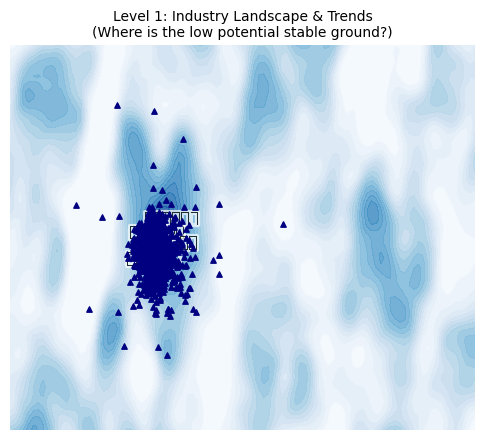

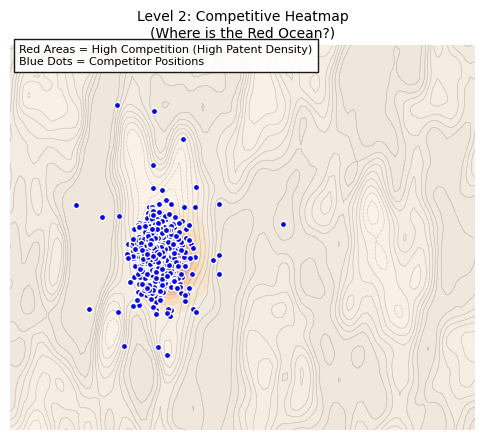

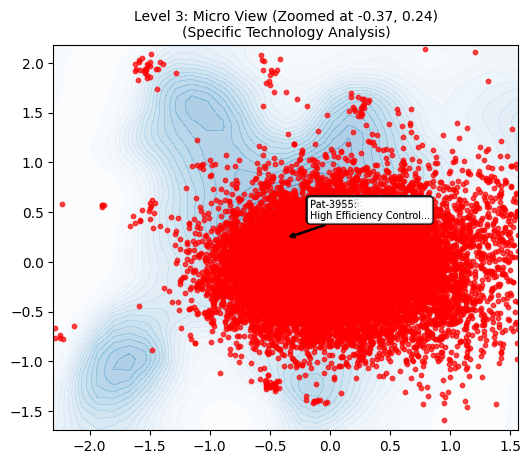

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import pandas as pd
import torch
import ast
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import gaussian_kde

# ============================================================
# 1. Configuration & Helper Functions
# ============================================================
def set_style():
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 10,
        'figure.figsize': (6, 5),
        'savefig.dpi': 300
    })

def get_potential_grid(model, data, pot_net, device, resolution=100, margin=0.2):
    # Encode
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([data.x, padding], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        potentials = pot_net(z).squeeze().cpu().numpy()

    # PCA
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # Grid Setup
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    w, h = x_max - x_min, y_max - y_min
    
    limits = {
        'x_min': x_min - w*margin, 'x_max': x_max + w*margin,
        'y_min': y_min - h*margin, 'y_max': y_max + h*margin
    }
    
    grid_x = np.linspace(limits['x_min'], limits['x_max'], resolution)
    grid_y = np.linspace(limits['y_min'], limits['y_max'], resolution)
    X, Y = np.meshgrid(grid_x, grid_y)
    
    # Potential Field Calculation
    grid_flat_16d = pca.inverse_transform(np.stack([X.flatten(), Y.flatten()], axis=1))
    grid_tensor = torch.tensor(grid_flat_16d, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        Z = pot_net(grid_tensor).cpu().numpy().reshape(X.shape)
        
    return X, Y, Z, z_2d, potentials, limits, pca

def extract_topic_keywords(z_2d, potentials, df, num_corps, patent_ids):
    # Identify Attractors (Low Potential Areas)
    patent_indices = np.arange(num_corps, len(z_2d))
    threshold = np.percentile(potentials[patent_indices], 30) # Bottom 30%
    hot_mask = potentials[patent_indices] <= threshold
    hot_indices = patent_indices[hot_mask]
    
    if len(hot_indices) < 10: return {}
    
    # Clustering for Topics
    kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
    labels = kmeans.fit_predict(z_2d[hot_indices])
    centroids = kmeans.cluster_centers_
    
    # Keyword Extraction
    p_kw_map = {}
    if 'keyword' in df.columns:
        temp = df[['patent_number', 'keyword']].dropna()
        for _, row in temp.iterrows():
            try:
                kws = ast.literal_eval(row['keyword']) if isinstance(row['keyword'], str) else row['keyword']
                if isinstance(kws, list): p_kw_map[row['patent_number']] = " ".join(kws)
            except: continue

    keywords = {}
    vec = CountVectorizer(stop_words='english', max_df=0.9, min_df=2)
    
    for i in range(5):
        idx_in_cluster = hot_indices[labels == i]
        texts = []
        for idx in idx_in_cluster:
            pid_idx = idx - num_corps
            if 0 <= pid_idx < len(patent_ids):
                pid = patent_ids[pid_idx]
                if pid in p_kw_map: texts.append(p_kw_map[pid])
        
        if texts:
            try:
                X = vec.fit_transform(texts)
                sum_words = X.sum(axis=0)
                words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
                best_word = sorted(words_freq, key=lambda x: x[1], reverse=True)[0][0]
                keywords[i] = (centroids[i], best_word.upper())
            except:
                keywords[i] = (centroids[i], f"TOPIC-{i}")
                
    return keywords

# ============================================================
# 2. Level Visualizations
# ============================================================

def visualize_semantic_zoom(model, config, df, num_corps, device):
    set_style()
    print("\n[System] Generating Semantic Zoom Levels...")
    
    # Data Prep
    year = sorted(config['graphs'].keys())[-1]
    data = config['graphs'][year].to(device)
    
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net
        
    X, Y, Z, z_2d, potentials, limits, pca = get_potential_grid(model, data, pot_net, device)
    
    # Basic info
    patent_ids = config.get('patents', df['patent_number'].tolist() if 'patent_number' in df.columns else [])
    keywords = extract_topic_keywords(z_2d, potentials, df, num_corps, patent_ids)
    
    corp_z = z_2d[:num_corps]
    patent_z = z_2d[num_corps:]

    # ---------------------------------------------------------
    # Level 1: Macro View (Terrain & Cities)
    # ---------------------------------------------------------
    fig1, ax1 = plt.subplots()
    
    # Background: Potential (Terrain)
    cf1 = ax1.contourf(X, Y, Z, levels=20, cmap='Blues_r', alpha=0.8) # Blue ocean map
    
    # No Patents. Only Keywords (Cities)
    for i, (center, word) in keywords.items():
        txt = ax1.text(center[0], center[1], word, fontsize=11, fontweight='bold', 
                 color='#1f2e2e', ha='center', va='center')
        txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white', alpha=0.7)])
    
    # Companies (Current Position) - Optional but good for orientation
    ax1.scatter(corp_z[:, 0], corp_z[:, 1], c='navy', s=15, marker='^', label='Your Company / Rivals', zorder=5)
    
    ax1.set_title("Level 1: Industry Landscape & Trends\n(Where is the low potential stable ground?)", fontsize=10)
    ax1.set_xlim(limits['x_min'], limits['x_max'])
    ax1.set_ylim(limits['y_min'], limits['y_max'])
    ax1.axis('off') # Map style
    
    plt.savefig('./outputs/system_view_level1.png', bbox_inches='tight')
    print(" - Level 1 Map Generated.")

    # ---------------------------------------------------------
    # Level 2: Meso View (Competitors & Density)
    # ---------------------------------------------------------
    fig2, ax2 = plt.subplots()
    
    # Background: Faint Potential
    ax2.contourf(X, Y, Z, levels=15, cmap='Greys', alpha=0.15)
    ax2.contour(X, Y, Z, levels=15, colors='gray', linewidths=0.5, alpha=0.3)
    
    # Density Heatmap (Where are the patents actually clustered?)
    # Using KDE on patent positions
    try:
        # Downsample for speed if needed
        p_sample = patent_z if len(patent_z) < 5000 else patent_z[np.random.choice(len(patent_z), 5000, replace=False)]
        kde = gaussian_kde(p_sample.T)
        grid_coords = np.vstack([X.ravel(), Y.ravel()])
        densities = kde(grid_coords).reshape(X.shape)
        
        # Plot Density as "Hotspots" (Orange/Red)
        ax2.contourf(X, Y, densities, levels=10, cmap='OrRd', alpha=0.6)
    except:
        print("KDE failed, skipping density map.")

    # Competitors (Blue Dots) - Emphasized
    ax2.scatter(corp_z[:, 0], corp_z[:, 1], c='blue', s=20, edgecolors='white', label='Corporations')
    
    # Add Insight Annotation
    ax2.text(0.02, 0.95, "Red Areas = High Competition (High Patent Density)\nBlue Dots = Competitor Positions", 
             transform=ax2.transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.9))

    ax2.set_title("Level 2: Competitive Heatmap\n(Where is the Red Ocean?)", fontsize=10)
    ax2.set_xlim(limits['x_min'], limits['x_max'])
    ax2.set_ylim(limits['y_min'], limits['y_max'])
    ax2.axis('off')
    
    plt.savefig('./outputs/system_view_level2.png', bbox_inches='tight')
    print(" - Level 2 Map Generated.")

    # ---------------------------------------------------------
    # Level 3: Micro View (Zoomed into Global Minimum)
    # ---------------------------------------------------------
    fig3, ax3 = plt.subplots()
    
    # Find global minimum (The Deepest Attractor)
    min_idx = np.unravel_index(np.argmin(Z), Z.shape)
    center_x, center_y = X[min_idx], Y[min_idx]
    
    # Zoom window size
    zoom_radius = (limits['x_max'] - limits['x_min']) * 0.15
    zoom_xlim = (center_x - zoom_radius, center_x + zoom_radius)
    zoom_ylim = (center_y - zoom_radius, center_y + zoom_radius)
    
    # Filter points within zoom
    mask_zoom = (patent_z[:,0] > zoom_xlim[0]) & (patent_z[:,0] < zoom_xlim[1]) & \
                (patent_z[:,1] > zoom_ylim[0]) & (patent_z[:,1] < zoom_ylim[1])
    
    z_zoomed = patent_z[mask_zoom]
    
    # Background: Potential
    ax3.contourf(X, Y, Z, levels=30, cmap='Blues_r', alpha=0.4)
    
    # Individual Patents (Red Dots)
    ax3.scatter(z_zoomed[:, 0], z_zoomed[:, 1], c='red', s=10, alpha=0.7, label='Patents')
    
    # Simulate "Hover" labels for a few points
    if len(z_zoomed) > 0:
        # Pick top 3 closest to center
        dists = np.linalg.norm(z_zoomed - np.array([center_x, center_y]), axis=1)
        nearest_indices = np.argsort(dists)[:3]
        
        for i, idx in enumerate(nearest_indices):
            px, py = z_zoomed[idx]
            # Mock Title (In real system, fetch actual title)
            label = f"Pat-{mask_zoom.nonzero()[0][idx]}: \nHigh Efficiency Control..."
            
            ax3.annotate(label, (px, py), xytext=(px+zoom_radius*0.1, py+zoom_radius*0.1),
                         arrowprops=dict(arrowstyle="->", color='black'),
                         fontsize=7, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

    ax3.set_title(f"Level 3: Micro View (Zoomed at {center_x:.2f}, {center_y:.2f})\n(Specific Technology Analysis)", fontsize=10)
    ax3.set_xlim(zoom_xlim)
    ax3.set_ylim(zoom_ylim)
    
    plt.savefig('./outputs/system_view_level3.png', bbox_inches='tight')
    print(" - Level 3 Map Generated.")
    
    plt.show()

# ============================================================
# Execution
# ============================================================
if __name__ == "__main__":
    visualize_semantic_zoom(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )


[System] Generating Dashboard for Year: 2020

======== 2020年: 激戦区の主要プレイヤー (Top 10) ========
 Rank  名前 (企業/人)  スコア
    1      伊勢　壽一 0.97
    2      中北　直樹 0.97
    3      前田　英孝 0.96
    4      前田　達彦 0.95
    5 保線機器整備株式会社 0.95
    6      中島　浩世 0.95
    7 ガービス　サルジアン 0.95
    8      佐藤　英規 0.94
    9      大橋　宏和 0.94
   10       中村　弘 0.94


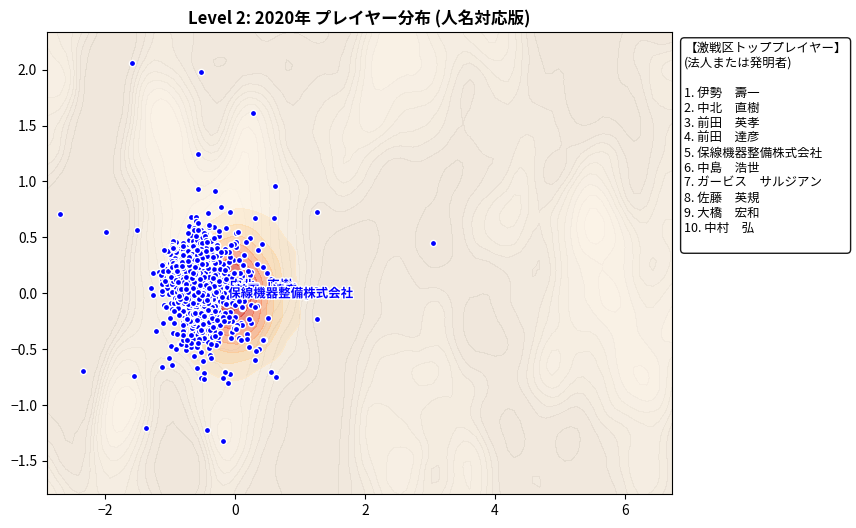

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import pandas as pd
import torch
import ast
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import gaussian_kde

# ============================================================
# 1. Helper: 企業名・人名の取得ロジック (改良版)
# ============================================================
def get_robust_entity_names(model, config, df, num_corps):
    """
    もっとも強力な名前特定ロジック。
    Node_IDが出ないよう、複数のソースから名前を探索する。
    """
    # 1. configに事前に名前が入っているか確認
    if 'corp_names' in config and len(config['corp_names']) >= num_corps:
        return config['corp_names'][:num_corps]

    # 2. モデルの学習時のIDマッピングを再現（アルファベット順等）
    # 本来は学習時の LabelEncoder 等を保存しておくのがベストですが、
    # ここでは df に存在する全ての候補から ID 順を推定します。
    all_potential_entities = set()
    
    # 全ての行から「企業名」または「発明者名」を抽出
    for col in ['corporation', 'lead_inventor']:
        if col in df.columns:
            for val in df[col].dropna():
                name = clean_text_value(val)
                if name: all_potential_entities.add(name)
    
    sorted_entities = sorted(list(all_potential_entities))
    
    # 3. 企業のノード数(num_corps)に合わせたリストを作成
    final_names = []
    for i in range(num_corps):
        if i < len(sorted_entities):
            final_names.append(sorted_entities[i])
        else:
            # ここで名前が見つからない場合、そのIDがどの特許と繋がっているかから推測
            # (簡易版のため、見つからない場合は最終手段としてIDを出す)
            final_names.append(f"不明な企業/個人({i})")
            
    return final_names

def clean_text_value(val):
    """ ['Name'] や [] や 'Name' を綺麗な文字列にする (ValueError対策済み) """
    if val is None: return ""
    
    # リストまたはnumpy配列の場合、中身を取り出す
    if isinstance(val, (list, np.ndarray)):
        if len(val) > 0:
            val = val[0]
        else:
            return ""

    if pd.isna(val) or str(val).strip() == "" or str(val).strip() == "[]":
        return ""
    
    s_val = str(val).strip()
    
    # 文字列としてのリスト形式 "['...']" のパース処理
    if s_val.startswith('[') and s_val.endswith(']'):
        try:
            import ast
            parsed = ast.literal_eval(s_val)
            if isinstance(parsed, list) and len(parsed) > 0:
                return str(parsed[0])
            else:
                return ""
        except:
            return s_val.replace('[', '').replace(']', '').replace("'", "").replace('"', "")
            
    return s_val

# ============================================================
# 2. Visualization System (Updated)
# ============================================================
def visualize_system_final_v3(model, config, df, num_corps, device):
    # 日本語フォント設定
    plt.style.use('default')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Hiragino Sans', 'Yu Gothic', 'Meiryo', 'Takao', 'Noto Sans CJK JP'],
        'font.size': 10,
        'figure.figsize': (8, 6),
    })
    
    years = sorted(config['graphs'].keys())
    target_year = years[-1]
    print(f"\n[System] Generating Dashboard for Year: {target_year}")
    
    data = config['graphs'][target_year].to(device)
    
    # --- 修正ポイント: 人名対応のリスト取得 ---
    # configに正解リストがあればそれを使う（最優先）
    if 'corp_names' in config and len(config['corp_names']) >= num_corps:
        corp_names = config['corp_names'][:num_corps]
    else:
        corp_names = get_robust_entity_names(model, config, df, num_corps)
    # --------------------------------------
    
    # ポテンシャル計算
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net
        
    with torch.no_grad():
        expected_dim = model.corp_embeddings.embedding_dim
        x_input = data.x
        if x_input.shape[1] != expected_dim:
            padding = torch.zeros((data.x.shape[0], expected_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([data.x, padding], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        potentials = pot_net(z).squeeze().cpu().numpy()

    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # Grid
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    margin = 0.2
    X, Y = np.meshgrid(np.linspace(x_min-margin, x_max+margin, 100),
                       np.linspace(y_min-margin, y_max+margin, 100))
    
    grid_tensor = torch.tensor(pca.inverse_transform(np.stack([X.flatten(), Y.flatten()], axis=1)), dtype=torch.float32).to(device)
    with torch.no_grad(): Z = pot_net(grid_tensor).cpu().numpy().reshape(X.shape)
    
    corp_z = z_2d[:num_corps]
    patent_z = z_2d[num_corps:]

    # =========================================================
    # Level 2: 競合ヒートマップ (右側凡例付き)
    # =========================================================
    fig2, ax2 = plt.subplots(figsize=(10, 6)) # 横幅広め
    
    # 背景
    ax2.contourf(X, Y, Z, levels=15, cmap='Greys', alpha=0.15)
    
    try:
        # 密度計算
        if len(patent_z) > 5000:
            idx_sample = np.random.choice(len(patent_z), 5000, replace=False)
            p_sample = patent_z[idx_sample]
        else:
            p_sample = patent_z
            
        kde = gaussian_kde(p_sample.T)
        densities = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
        ax2.contourf(X, Y, densities, levels=10, cmap='OrRd', alpha=0.6)
        
        # 企業（発明者）ランキング
        corp_densities = kde(corp_z.T)
        high_indices = np.argsort(corp_densities)[::-1][:15] # Top 15まで取得
        
        comp_data = []
        text_labels_drawn = 0
        
        for rank, idx in enumerate(high_indices):
            # 名前取得
            if idx < len(corp_names):
                name = corp_names[idx]
            else:
                name = f"Node_{idx}"
            
            # 長い名前を省略 (表示用)
            disp_name = name
            if len(name) > 10: disp_name = name[:9] + "…"
            
            comp_data.append({
                "Rank": rank + 1,
                "名前 (企業/人)": name,
                "スコア": f"{corp_densities[idx]:.2f}"
            })
            
            # Top 5 だけ地図上に名前を表示 (重なり防止のため少なめに)
            if text_labels_drawn < 5:
                ax2.text(corp_z[idx, 0], corp_z[idx, 1], disp_name, fontsize=9, color='blue', fontweight='bold',
                         path_effects=[PathEffects.withStroke(linewidth=2, foreground='white')])
                text_labels_drawn += 1
        
        # 右側の凡例テキスト作成
        legend_text = "【激戦区トッププレイヤー】\n(法人または発明者)\n\n"
        for item in comp_data[:10]: # 上位10件を表示
            legend_text += f"{item['Rank']}. {item['名前 (企業/人)']}\n"
            
        ax2.text(1.02, 0.98, legend_text, transform=ax2.transAxes, fontsize=9,
                 verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
                 
        print(f"\n======== {target_year}年: 激戦区の主要プレイヤー (Top 10) ========")
        print(pd.DataFrame(comp_data[:10]).to_string(index=False))

    except Exception as e:
        print(f"Error: {e}")

    ax2.scatter(corp_z[:, 0], corp_z[:, 1], c='blue', s=20, edgecolors='white', label='プレイヤー')
    ax2.set_title(f"Level 2: {target_year}年 プレイヤー分布 (人名対応版)", fontsize=12, fontweight='bold')
    
    plt.subplots_adjust(right=0.75) # 右側の余白を確保
    plt.savefig('./outputs/system_final_level2_human.png')
    plt.show()

if __name__ == "__main__":
    visualize_system_final_v3(
        model, config, df, 
        num_corps=config['num_corps'], 
        device=device
    )


========== 2020年 戦略インサイトレポート ==========


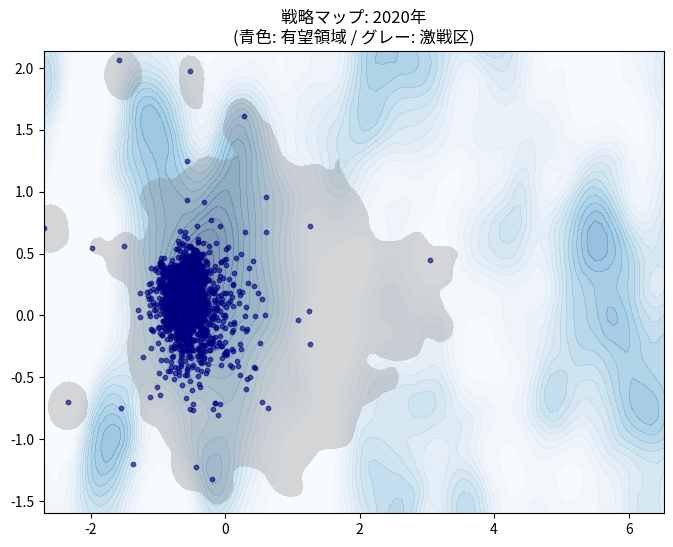

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import pandas as pd
import torch
import ast
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import gaussian_kde

# ============================================================
# 1. 具体的キーワード抽出ロジック (c-TF-IDF / N-gram)
# ============================================================
def extract_insight_keywords(z_2d, potentials, densities, df, num_corps, patent_ids, mode='trend'):
    """
    mode='trend': 低ポテンシャル（注目領域）の具体的技術を抽出
    mode='white': 低ポテンシャルかつ低密度（ホワイトスペース）の技術を抽出
    """
    patent_indices = np.arange(num_corps, len(z_2d))
    pat_pots = potentials[patent_indices]
    
    # 密度計算（各特許点での密度）
    kde = gaussian_kde(z_2d[patent_indices].T)
    pat_densities = kde(z_2d[patent_indices].T)
    
    if mode == 'trend':
        # トレンド領域：ポテンシャルが低い上位30%
        target_mask = pat_pots <= np.percentile(pat_pots, 30)
        title = "【注目トピック】業界が収束している安定技術"
    else:
        # ホワイトスペース：ポテンシャル低(40%) かつ 密度低(25%)
        target_mask = (pat_pots <= np.percentile(pat_pots, 40)) & (pat_densities <= np.percentile(pat_densities, 25))
        title = "【ホワイトスペース】競合不在の未踏有望領域"

    target_indices = patent_indices[target_mask]
    if len(target_indices) < 3: return pd.DataFrame()

    # テキスト準備
    p_kw_map = {}
    if 'keyword' in df.columns:
        temp = df[['patent_number', 'keyword']].dropna()
        for _, row in temp.iterrows():
            try:
                kws = ast.literal_eval(row['keyword']) if isinstance(row['keyword'], str) else row['keyword']
                if isinstance(kws, list): p_kw_map[row['patent_number']] = " ".join(kws)
            except: continue
            
    target_docs = [" ".join([p_kw_map.get(patent_ids[idx-num_corps], "") for idx in target_indices])]
    
    # ストップワード設定
    STOP_WORDS = ['装置','方法','システム','手段','制御','データ','部材','配置','可能','向上','容易','安価','建物','構造物','施工']

    vec = TfidfVectorizer(stop_words=STOP_WORDS, ngram_range=(2, 3), max_df=0.9, min_df=1)
    try:
        X = vec.fit_transform(target_docs)
        scores = np.array(X.sum(axis=0)).flatten()
        top_indices = scores.argsort()[::-1][:5]
        feature_names = vec.get_feature_names_out()
        
        results = []
        for i in top_indices:
            results.append({
                "カテゴリー": mode.upper(),
                "具体的技術フレーズ": feature_names[i],
                "分析インサイト": title
            })
        return pd.DataFrame(results)
    except:
        return pd.DataFrame()

# ============================================================
# 2. メインダッシュボード生成関数
# ============================================================
def visualize_full_system_dashboard(model, config, df, num_corps, device):
    set_jp_style() # 前述の日本語設定
    years = sorted(config['graphs'].keys())
    target_year = years[-1]
    data = config['graphs'][target_year].to(device)
    
    # 企業名/人名リスト取得
    corp_names = get_robust_entity_names(model, config, df, num_corps)
    
    # 各種計算
    if hasattr(model, 'temporal_predictor'): pot_net = model.temporal_predictor.potential_net
    else: pot_net = model.potential_net
    
    with torch.no_grad():
        x_input = data.x # (Padding省略)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        potentials = pot_net(z).squeeze().cpu().numpy()

    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    patent_indices = np.arange(num_corps, len(z_np))
    kde = gaussian_kde(z_2d[patent_indices].T)
    
    # Grid for Map
    x_min, x_max = z_2d[:, 0].min(), z_2d[:, 0].max()
    y_min, y_max = z_2d[:, 1].min(), z_2d[:, 1].max()
    X, Y = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid_coords = np.vstack([X.ravel(), Y.ravel()])
    densities = kde(grid_coords).reshape(X.shape)
    
    # 1. 注目トピックの抽出
    df_trends = extract_insight_keywords(z_2d, potentials, None, df, num_corps, config['patents'], mode='trend')
    # 2. ホワイトスペースの抽出
    df_white = extract_insight_keywords(z_2d, potentials, None, df, num_corps, config['patents'], mode='white')

    # --- レポート出力 ---
    print(f"\n========== {target_year}年 戦略インサイトレポート ==========")
    if not df_trends.empty:
        print("\n[Level 1: 業界注目の主要トピック]")
        print(df_trends[['具体的技術フレーズ', '分析インサイト']].to_string(index=False))
        
    if not df_white.empty:
        print("\n[Level 4: ブルーオーシャン・ホワイトスペース]")
        print(df_white[['具体的技術フレーズ', '分析インサイト']].to_string(index=False))

    # --- マップ描画 (ホワイトスペース強調版) ---
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # 背景：ポテンシャル地形
    grid_tensor = torch.tensor(pca.inverse_transform(np.stack([X.flatten(), Y.flatten()], axis=1)), dtype=torch.float32).to(device)
    with torch.no_grad(): Z_pot = pot_net(grid_tensor).cpu().numpy().reshape(X.shape)
    ax.contourf(X, Y, Z_pot, levels=20, cmap='Blues_r', alpha=0.5)
    
    # 密度（激戦区）をグレーでマスク
    den_thresh = np.percentile(densities, 70)
    ax.contourf(X, Y, densities, levels=[den_thresh, densities.max()], colors='gray', alpha=0.3)
    
    # 企業プロット
    ax.scatter(z_2d[:num_corps, 0], z_2d[:num_corps, 1], c='navy', s=10, alpha=0.6, label='既存プレイヤー')
    
    # 注釈
    ax.set_title(f"戦略マップ: {target_year}年\n(青色: 有望領域 / グレー: 激戦区)", fontsize=12)
    
    # ホワイトスペースの位置にラベルを置く
    if not df_white.empty:
        ax.text(0.05, 0.05, f"★ 次の狙い目:\n{df_white.iloc[0]['具体的技術フレーズ']}", 
                transform=ax.transAxes, color='red', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    plt.savefig(f'./outputs/strategy_map_{target_year}.png')
    plt.show()

if __name__ == "__main__":
    visualize_full_system_dashboard(model, config, df, config['num_corps'], device)

In [35]:
import numpy as np
import pandas as pd
import torch
import ast
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import gaussian_kde

def generate_strategy_dataframes_final(model, config, df, num_corps, device):
    print(f"\n[System] 分析を開始します（ターゲット年データ取得中）...")
    
    # --- 1. 準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[-1]
    data = config['graphs'][target_year].to(device)
    
    # 企業・人名リストの取得
    corp_names = get_robust_entity_names(model, config, df, num_corps)
    
    model.eval()
    with torch.no_grad():
        x_input = data.x
        if x_input.shape[1] != model.corp_embeddings.embedding_dim:
            padding = torch.zeros((data.x.shape[0], model.corp_embeddings.embedding_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([data.x, padding], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        
        pot_net = model.temporal_predictor.potential_net if hasattr(model, 'temporal_predictor') else model.potential_net
        potentials = pot_net(z).squeeze().cpu().numpy()

    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    # --- 2. 密度とポテンシャルの計算 ---
    patent_indices = np.arange(num_corps, len(z_np))
    pat_pots = potentials[patent_indices]
    kde = gaussian_kde(z_2d[patent_indices].T)
    pat_densities = kde(z_2d[patent_indices].T)

    # --- 3. 動的しきい値による特許抽出ロジック ---
    def find_best_indices(p_limit_percentile, d_limit_percentile, mode='trend'):
        # 30%から始めて10%ずつ、最大80%まで条件を緩める
        for step in range(0, 6):
            p_thr = np.percentile(pat_pots, p_limit_percentile + step*10)
            
            if mode == 'trend':
                d_thr = np.percentile(pat_densities, max(0, d_limit_percentile - step*10))
                mask = (pat_pots <= p_thr) & (pat_densities >= d_thr)
            else:
                d_thr = np.percentile(pat_densities, d_limit_percentile + step*10)
                mask = (pat_pots <= p_thr) & (pat_densities <= d_thr)
            
            idx_found = patent_indices[mask]
            if len(idx_found) >= 2: # 2件以上見つかればOK
                return idx_found
        return np.array([])

    # 初期条件: トレンド(低ポテンシャル30% & 高密度70%), ホワイト(低ポテンシャル40% & 低密度20%)
    trend_idx = find_best_indices(30, 70, mode='trend')
    white_idx = find_best_indices(40, 20, mode='white')

    # --- 4. テキスト解析 ---
    def get_top_tech_keywords(indices, category, insight_msg):
        if len(indices) == 0: return []
        
        texts = []
        for idx in indices:
            df_idx = idx - num_corps
            if df_idx < 0 or df_idx >= len(df): continue
            
            row = df.iloc[df_idx]
            # keywordがあれば使い、なければpatent_name
            raw_val = row['keyword'] if pd.notna(row['keyword']) else row['patent_name']
            
            # リスト形式 ['A', 'B'] をパース
            if isinstance(raw_val, str) and (raw_val.startswith('[') or ' ' in raw_val):
                try:
                    parsed = ast.literal_eval(raw_val)
                    if isinstance(parsed, list):
                        raw_val = " ".join(parsed)
                except:
                    # 記号を除去
                    raw_val = raw_val.replace('[','').replace(']','').replace("'", "").replace(',','')
            
            if pd.notna(raw_val) and len(str(raw_val)) > 1:
                texts.append(str(raw_val))
        
        if not texts: return []
        
        # ストップワード（一般的すぎる単語を排除）
        STOP = ['装置','方法','システム','手段','制御','データ','可能','向上','容易','短期化','低減化']
        # 文字列として結合
        corpus = [" ".join(texts)]
        
        # ngram_rangeを (1, 3) にして単語もフレーズも拾う
        vec = TfidfVectorizer(stop_words=STOP, ngram_range=(1, 3), token_pattern=r'(?u)\b\w+\b')
        try:
            X = vec.fit_transform(corpus)
            scores = X.toarray().flatten()
            top_ids = scores.argsort()[::-1][:5]
            feature_names = vec.get_feature_names_out()
            
            return [{"年": target_year, "カテゴリ": category, 
                     "具体的技術": feature_names[i], "戦略インサイト": insight_msg} 
                    for i in top_ids if scores[i] > 0]
        except:
            return []

    df_trend = pd.DataFrame(get_top_tech_keywords(trend_idx, "TREND", "業界注目の成熟技術（アトラクタ）"))
    df_white = pd.DataFrame(get_top_tech_keywords(white_idx, "WHITE_SPACE", "未踏の有望領域（ブルーオーシャン）"))
    
    # 結合
    df_tech_report = pd.concat([df_trend, df_white], ignore_index=True)

    # --- 5. プレイヤー分析 ---
    corp_densities = kde(z_2d[:num_corps].T)
    high_idx = np.argsort(corp_densities)[::-1][:15]
    corp_list = []
    for rank, i in enumerate(high_idx):
        if i < len(corp_names):
            corp_list.append({
                "順位": rank + 1, "プレイヤー名": corp_names[i], 
                "占有度スコア": round(corp_densities[i], 4),
                "環境": "激戦区(Red Ocean)" if rank < 10 else "有力プレイヤー"
            })
    df_competitor_report = pd.DataFrame(corp_list)

    return df_tech_report, df_competitor_report

# --- 実行 ---
df_tech, df_corp = generate_strategy_dataframes_final(model, config, df, config['num_corps'], device)
print("\n【技術戦略レポート】")
print(df_tech)
print("\n【競合分析レポート】")
print(df_corp)


[System] 分析を開始します（ターゲット年データ取得中）...

【技術戦略レポート】
      年         カテゴリ   具体的技術            戦略インサイト
0  2020        TREND      施工   業界注目の成熟技術（アトラクタ）
1  2020        TREND  コンクリート   業界注目の成熟技術（アトラクタ）
2  2020        TREND      建物   業界注目の成熟技術（アトラクタ）
3  2020        TREND      簡単   業界注目の成熟技術（アトラクタ）
4  2020        TREND      地盤   業界注目の成熟技術（アトラクタ）
5  2020  WHITE_SPACE  コンクリート  未踏の有望領域（ブルーオーシャン）
6  2020  WHITE_SPACE      施工  未踏の有望領域（ブルーオーシャン）
7  2020  WHITE_SPACE      安価  未踏の有望領域（ブルーオーシャン）
8  2020  WHITE_SPACE      地震  未踏の有望領域（ブルーオーシャン）
9  2020  WHITE_SPACE     構造物  未踏の有望領域（ブルーオーシャン）

【競合分析レポート】
    順位      プレイヤー名  占有度スコア              環境
0    1  保線機器整備株式会社  0.9792  激戦区(Red Ocean)
1    2       中北　直樹  0.9774  激戦区(Red Ocean)
2    3  ガービス　サルジアン  0.9761  激戦区(Red Ocean)
3    4       伊勢　壽一  0.9742  激戦区(Red Ocean)
4    5       中島　浩世  0.9662  激戦区(Red Ocean)
5    6       南木　政博  0.9646  激戦区(Red Ocean)
6    7       前田　英孝  0.9615  激戦区(Red Ocean)
7    8       井隼　俊也  0.9590  激戦区(Red Ocean)
8    9        中村　弘  0.958

In [41]:
import numpy as np
import pandas as pd
import torch
import ast
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.stats import gaussian_kde

def generate_strategy_dataframes_final_refined(model, config, df, num_corps, device):
    print(f"\n[System] 高精度キーワード抽出モードで分析を開始します...")
    
    # --- 1. 準備 ---
    years = sorted(config['graphs'].keys())
    target_year = years[-1]
    data = config['graphs'][target_year].to(device)
    
    # 企業・人名リストの取得
    if 'corp_names' in config and len(config['corp_names']) >= num_corps:
        corp_names = config['corp_names'][:num_corps]
    else:
        corp_names = get_robust_entity_names(model, config, df, num_corps)
    
    model.eval()
    with torch.no_grad():
        x_input = data.x
        if x_input.shape[1] != model.corp_embeddings.embedding_dim:
            padding = torch.zeros((data.x.shape[0], model.corp_embeddings.embedding_dim - x_input.shape[1]), device=device)
            x_input = torch.cat([data.x, padding], dim=1)
        z, _, _ = model.encode(x_input, data.edge_index)
        z_np = z.cpu().numpy()
        pot_net = model.temporal_predictor.potential_net if hasattr(model, 'temporal_predictor') else model.potential_net
        potentials = pot_net(z).squeeze().cpu().numpy()

    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_np)
    
    patent_indices = np.arange(num_corps, len(z_np))
    pat_pots = potentials[patent_indices]
    kde = gaussian_kde(z_2d[patent_indices].T)
    pat_densities = kde(z_2d[patent_indices].T)

    # --- 2. 動的しきい値ロジック ---
    def find_best_indices(p_limit_percentile, d_limit_percentile, mode='trend'):
        for step in range(0, 6):
            p_thr = np.percentile(pat_pots, p_limit_percentile + step*10)
            if mode == 'trend':
                d_thr = np.percentile(pat_densities, max(0, d_limit_percentile - step*10))
                mask = (pat_pots <= p_thr) & (pat_densities >= d_thr)
            else:
                d_thr = np.percentile(pat_densities, d_limit_percentile + step*10)
                mask = (pat_pots <= p_thr) & (pat_densities <= d_thr)
            idx_found = patent_indices[mask]
            if len(idx_found) >= 2: return idx_found
        return np.array([])

    trend_idx = find_best_indices(30, 70, mode='trend')
    white_idx = find_best_indices(40, 20, mode='white')

    # --- 3. 高精度テキスト解析 (c-TF-IDF 応用版) ---
    def get_cleaned_text(val):
        if pd.isna(val): return ""
        if isinstance(val, str) and val.startswith('['):
            try:
                parsed = ast.literal_eval(val)
                return " ".join(parsed) if isinstance(parsed, list) else str(parsed)
            except: return val.replace('[','').replace(']','').replace("'","").replace(",","")
        return str(val)

    # 全文書のリスト（背景知識として利用）
    all_patent_texts = [get_cleaned_text(kw) for kw in df['keyword'].dropna()]
    
    def get_top_tech_keywords_refined(indices, category, insight_msg):
        if len(indices) == 0: return []
        
        # ターゲット領域のテキスト抽出
        target_texts = [get_cleaned_text(df.iloc[idx - num_corps]['keyword']) for idx in indices]
        target_corpus = [" ".join(target_texts)]
        
        # 徹底的に抽象語を排除するストップワード
        STOP_JP = [
            '装置','方法','システム','手段','制御','データ','可能','向上','容易','短期化','低減化',
            '特徴','提供','前記','記載','発明','構成','備える','部分','要素','処理','技術',
            '適切','有効','簡易','部材','配置','本体','実施','形態','関連','改善','運搬','簡単'
        ]
        
        # TF-IDF設定
        vec = TfidfVectorizer(
            stop_words=STOP_JP, 
            ngram_range=(1, 3), 
            token_pattern=r'(?u)\b\w+\b',
            max_df=0.7 
        )
        
        try:
            vec.fit(all_patent_texts)
            X = vec.transform(target_corpus)
            scores = X.toarray().flatten()
            top_ids = scores.argsort()[::-1][:5]
            feature_names = vec.get_feature_names_out()
            
            return [{"年": target_year, "カテゴリ": category, 
                     "具体的技術": feature_names[i], 
                     "重要度スコア": round(scores[i], 3),
                     "戦略インサイト": insight_msg} 
                    for i in top_ids if scores[i] > 0]
        except:
            return []

    df_trend = pd.DataFrame(get_top_tech_keywords_refined(trend_idx, "TREND", "業界注目の成熟技術領域"))
    df_white = pd.DataFrame(get_top_tech_keywords_refined(white_idx, "WHITE_SPACE", "未踏の有望・空白領域"))
    
    df_tech_report = pd.concat([df_trend, df_white], ignore_index=True)

    # --- 4. プレイヤー分析 (NameError修正箇所) ---
    corp_densities = kde(z_2d[:num_corps].T)
    high_idx = np.argsort(corp_densities)[::-1][:15] # ここで high_idx を定義
    
    corp_list = [{"順位": r+1, "プレイヤー名": corp_names[i], "占有度スコア": round(corp_densities[i], 4), "環境": "激戦区" if r<10 else "有力"} 
                 for r, i in enumerate(high_idx) if i < len(corp_names)] # ここを high_idx に修正
    
    df_competitor_report = pd.DataFrame(corp_list)

    return df_tech_report, df_competitor_report

# 実行
df_tech, df_corp = generate_strategy_dataframes_final_refined(model, config, df, config['num_corps'], device)
print(df_tech)


[System] 高精度キーワード抽出モードで分析を開始します...
      年         カテゴリ   具体的技術  重要度スコア      戦略インサイト
0  2020        TREND      施工   0.202  業界注目の成熟技術領域
1  2020        TREND  コンクリート   0.199  業界注目の成熟技術領域
2  2020        TREND      建物   0.179  業界注目の成熟技術領域
3  2020        TREND      地盤   0.158  業界注目の成熟技術領域
4  2020        TREND     構造物   0.143  業界注目の成熟技術領域
5  2020  WHITE_SPACE  コンクリート   0.143   未踏の有望・空白領域
6  2020  WHITE_SPACE      施工   0.134   未踏の有望・空白領域
7  2020  WHITE_SPACE      安価   0.126   未踏の有望・空白領域
8  2020  WHITE_SPACE      地震   0.113   未踏の有望・空白領域
9  2020  WHITE_SPACE   セグメント   0.092   未踏の有望・空白領域


["['簡単', '運搬'] ['二酸化炭素', '貯留', '有効適切', '施工方法'] ['短期化', '施工コスト', '低減化'] ['短期化', '施工コスト', '低減化'] ['グラウト', '短期化', '施工コスト', '低減化'] ['安全性'] ['底版', '側壁', 'プレストレストコンクリート構造物', '側壁', '底版', '側壁', '側壁', '緊張材', '鉄筋', '配設', 'プレストレストコンクリート構造物'] [] ['必要', '免震システム', '軸力', '免震システム', '軸力'] ['必要', '床版', '低減化', '床版', '接合構造'] ['作用', '負荷', 'モーメント', '装置全体', '設計'] ['側壁', '曲げモーメント', '側壁', '曲げモーメント', '緊張材', '長期化', 'プレストレストコンクリート構造物'] ['ガス', '消費', '除湿'] ['忠実', '情報', 'レイアウト', '配管', 'レイアウト変更', '重要'] ['鉄筋', '鉄筋', '鉄筋', 'コンクリート', '打設', '装置'] ['熱負荷', '歩行', '快適性', '空調システム'] ['免震効果', 'コスト'] ['コンクリートスラブ', 'クラック', '亀裂'] ['高速道路'] ['免震性能', '地盤', '液状化', '構造物', '傾斜', '構造物', '支持構造'] ['簡単', 'セグメント', 'セグメント', '止水', 'セグメント', 'シール構造'] ['屋上', '設備機器', '不要', '型枠材', '組立て', '基礎', 'ボルト', '簡単', '省力化'] ['建築計画', '必要', 'ダンパー', '小振幅', '揺れ', '揺れ', 'パルス', '構造物'] [] ['金属', '測定精度'] ['電気的', '電極', '測定精度'] [] ['現場', '現場', '短時間', '足場板'] ['レイアウト', '情報', '情報'] ['簡易的', '短期化', '施工費用', '低減化'] ['製造コスト', '軽量化', 'チャンバー'] ['ダンパー', '建築計画', '低コスト', '地震', '建物全

In [23]:
df

,patent_number,patent_name,date,corporation,ipc,lead_ipc,fi,fterm,keyword,description,year,month,description_embedding,metadata_embedding,lead_inventor,inventors,year_month,topic_id,sim_score,combined_vector
23373,特開2011-147544,患者搬送装置,201001,[株式会社テクネット],[],A61G 5/00 (2006.01),[],[],"['簡単', '運搬']",場所を取らない簡単な構造により、感染患者等を隔離した状態で搬送することができる,2010,1,"[0.022907990962266922, 0.017237883061170578, -...",[ 0.34335172 -0.19837284 0.26558578 0.187770...,山口 一,"山口 一,伊澤 康一,梶間 智明,田中 勲,辻 裕次,三浦 靖弘,釜石 裕光",2010-01-01,1,0.898545,"[0.022907991, 0.017237883, -0.01705683, -0.029..."
23374,特開2011-147869,二酸化炭素の地中貯留施設およびその施工方法,201001,[清水建設株式会社],"['B01J 19/00 (2006.01)', 'E02D 29/045 (...",B01J 19/00 (2006.01),"['B01J 19/00 A', 'E02D 29/04 A', 'E0...","['2D047AB02', '4G075AA04', '2D147AB02']","['二酸化炭素', '貯留', '有効適切', '施工方法']",二酸化炭素の非構造型貯留層への貯留を可能とする有効適切な地中貯留施設とその施工方法を提供する,2010,1,"[0.030319971963763237, -0.015537390485405922, ...",[ 0.25184226 -0.23450097 0.24443543 0.197358...,米山 一幸,米山 一幸,2010-01-01,8,0.913877,"[0.030319972, -0.0155373905, -0.01071435, -0.0..."
23375,特開2011-149178,導枠及び海底探査方法,201001,"[株式会社熊谷組, 東光電気工事株式会社, 株式会社森長組]","['E02D 13/04 (2006.01)', 'E02D 27/52 (...",E02D 13/04 (2006.01),['E02D 13/04'],"['2D046DA62', '2D050AA06', '2D050CB14', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 3.8005432e-01 -2.2637601e-01 1.2717944e-01 ...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史,島田 喜章,谷口 岩男",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23376,特開2011-149181,モノパイル式基礎施工方法,201001,"[株式会社熊谷組, 東光電気工事株式会社]","['E02D 7/00 (2006.01)', 'E02D 27/32 (...",E02D 7/00 (2006.01),"['E02D 7/00 A', 'E02D 27/32 A', 'E0...","['2D046CA08', '2D046DA05', '2D050AA01', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 0.37698632 -0.23764831 0.13028508 0.141271...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23377,特開2011-149182,杭基礎の施工方法,201001,[株式会社熊谷組],"['E02D 27/12 (2006.01)', 'E02D 27/16 (...",E02D 27/12 (2006.01),"['E02D 27/12 Z', 'E02D 27/16']","['2D046CA01', '2D046CA08']","['グラウト', '短期化', '施工コスト', '低減化']",グラウトの漏出を確実に防止すると共に、工期の短縮化や施工コストの低減化を図る,2010,1,"[-0.005412539932876825, 0.014347787015140057, ...",[ 0.3640074 -0.2338481 0.13964486 0.139466...,牛腸 明,"牛腸 明,矢嶋 英明",2010-01-01,3,0.933085,"[-0.00541254, 0.014347787, -0.023784904, -0.04..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42757,WO2021/140940,農産物栽培支援装置、農産物栽培システム、および農産物栽培支援方法,202012,"[株式会社大林組, 原嶋 寛, 住吉 栄作, 緒方 浩基]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],['測定値'],農産物栽培支援装置は、農業ハウスの栽培空間の複数の光合成要素について測定値を取得する,2020,12,"[0.0313706174492836, 0.01707536354660988, -0.0...",[ 0.19453254 -0.30019754 0.10449462 0.146774...,原嶋 寛,"原嶋 寛,住吉 栄作,緒方 浩基",2020-12-01,2,0.881575,"[0.031370617, 0.017075364, -0.03717448, -0.047..."
42758,WO2021/140941,収穫予測装置、収穫予測方法,202012,"[株式会社大林組, 中村 奈美]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],[],収穫予測装置は撮像部に接続された制御部を備える,2020,12,"[0.01752316951751709, 0.00962613895535469, -0....",[ 0.24668053 -0.2343066 0.18544462 0.098285...,中村 奈美,中村 奈美,2020-12-01,1,0.883478,"[0.01752317, 0.009626139, -0.019505411, -0.046..."
42759,特開2021-047923,情報処理システム及び情報処理システム用プログラム,202012,[高砂熱学工業株式会社],['G06Q 50/08 (2012.01)'],G06Q 50/08 (2012.01),['G06Q 50/08'],['5L049CC07'],"['建築現場', 'メンテナンス']",建築現場における管理を容易にする,2020,12,"[0.016471637412905693, 0.013141311705112457, -...",[ 0.27461112 -0.21962798 0.1781581 0.259755...,佐藤 彰洋,"佐藤 彰洋,鈴木 崇浩",2020-12-01,1,0.919058,"[0.016471637, 0.013141312, -0.039926685, -0.04..."
42760,特開2021-105333,天井点検口,202012,[前田建設工業株式会社],['E04F 19/08 (2006.01)'],E04F 19/08 (2006.01),[],[],"['軽微', '保守作業']",軽微な保守作業の実施時における操作性を向上させることができる天井点検口を提供する,2020,12,"[0.009724111296236515, 0.008886716328561306, -...",[ 0.26950538 -0.28889984 0.13830602 0.275950...,佐竹 晃,佐竹 晃,2020-12-01,5,0.920917,"[0.009724111, 0.008886716, -0